# Study 3: Trust Behaviors in Collective Chat During Tornado Events

**Research Context:** Analyzing YouTube live stream comments from weather streamers during severe weather events to understand how trust operates as collective infrastructure.

**Data:** 1.1M+ comments from Max Velocity, Ryan Hall Y'all, and Texas Weather Center livestreams

**Analysis Pipeline:**
1. Raw data exploration (full 1.1M dataset)
2. Bot & moderator identification and flagging
3. @mention exploration & conversation threading
4. Cleaned data analysis (human-only)
5. Substantive comments filtering (remove low-effort + spam/donations)
6. Visualizations for CHI/CSCW publication
7. Generate stratified coding sample (2,000 comments) - REVISED STRATEGY
8. Export summary tables and results

**UPDATES IN THIS VERSION:**
- Added spam/donation detection for promotional and donation messages
- Revised sampling strategy to avoid over-sampling high-frequency periods
- Added temporal exclusion (first 15 minutes) to reduce greeting bias
- Changed from hourly to half-hourly block sampling for better distribution
- Improved documentation of @mention analysis

---

## Setup & Data Loading

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')  # Colorblind-friendly palette for publication
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
# CONFIGURE YOUR PATH HERE
DATA_PATH = '/content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[Complete] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/youtube_comments_combined.csv'

# Load data
print("Loading data...")
df = pd.read_csv(DATA_PATH)

print(f"\n✓ Data loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading data...

✓ Data loaded successfully!
Total rows: 1,116,371
Columns: ['creator', 'event_date', 'username', 'channel_url', 'comment_timestamp', 'comment_text', 'word_count']

First few rows:


,creator,event_date,username,channel_url,comment_timestamp,comment_text,word_count
0,max,2025-03-14,Max Velocity - Severe Weather Center,youtube.com/channel/UCvBVK2ymNzPLRJrgip2GeQQ,2025-03-14T18:46:27,1 MILLION SUBSCRIBER MERCH - http://shopmaxvelocity.net/,6
1,max,2025-03-14,TheEASguy,youtube.com/channel/UCvWgOMkZa_bXYV2TWiPz0kw,2025-03-14T19:04:54,It’s not a wind driven high risk,7
2,max,2025-03-14,Zack Venzon,youtube.com/channel/UCDOylYGEBL5NKSFd-qxWHcw,2025-03-14T19:04:55,only the 4th time a day 2 risk has ever been issued,12
3,max,2025-03-14,SEEKING TRUTH,youtube.com/channel/UCPRH77HoLaPjSIXmcvGCnmg,2025-03-14T19:04:56,Y'all shingles are flying off roofs in West TX and sky is brown from dirt:face-fuchsia-tongue-ou...,15
4,max,2025-03-14,Chris Trucks,youtube.com/channel/UC7w6TbOR5wDepZUYcwW9q6A,2025-03-14T19:04:56,"same. well, just over 45.",5


In [4]:
# Basic preprocessing
print("Preprocessing data...")

# Convert timestamps to datetime
df['comment_datetime'] = pd.to_datetime(df['comment_timestamp'], errors='coerce')
df['event_date'] = pd.to_datetime(df['event_date'], errors='coerce')

# Timezone handling: YouTube timestamps are in UTC, convert to Eastern Time
print("  Converting timestamps from UTC to Eastern Time...")
if df['comment_datetime'].dt.tz is None:
    # Timestamps are naive (no timezone info) - localize to UTC first
    df['comment_datetime'] = df['comment_datetime'].dt.tz_localize('UTC')
df['comment_datetime'] = df['comment_datetime'].dt.tz_convert('US/Eastern')
print("  ✓ Timestamps converted to US/Eastern (handles EST/EDT automatically)")

# Extract temporal features (now in Eastern Time)
df['hour'] = df['comment_datetime'].dt.hour
df['day_of_week'] = df['comment_datetime'].dt.day_name()
df['date'] = df['comment_datetime'].dt.date

# Calculate time since event start (per event-creator combination)
# Note: This is timezone-agnostic since it's a time delta
df['time_from_event_start'] = df.groupby(['creator', 'event_date'])['comment_datetime'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 60  # Minutes since start
)

print("\n✓ Preprocessing complete")
print(f"Date range: {df['comment_datetime'].min()} to {df['comment_datetime'].max()}")
print(f"Timezone: {df['comment_datetime'].dt.tz}")

Preprocessing data...
  Converting timestamps from UTC to Eastern Time...
  ✓ Timestamps converted to US/Eastern (handles EST/EDT automatically)

✓ Preprocessing complete
Date range: 2025-03-14 14:46:27-04:00 to 2025-06-21 03:44:15-04:00
Timezone: US/Eastern


---
## SECTION 1: Raw Data Exploration (Full 1.1M Dataset)

Understanding the complete corpus before any filtering.

In [5]:
print("="*80)
print("SECTION 1: RAW DATA EXPLORATION")
print("="*80)

print("\n1. BASIC CORPUS STATISTICS (RAW DATA)")
print("-" * 80)
print(f"Total comments: {len(df):,}")
print(f"Unique users: {df['username'].nunique():,}")
print(f"Date range: {df['event_date'].min()} to {df['event_date'].max()}")
print(f"Number of event dates: {df['event_date'].nunique()}")

print("\n2. BREAKDOWN BY CREATOR (RAW DATA)")
print("-" * 80)
creator_stats = df.groupby('creator').agg({
    'comment_text': 'count',
    'username': 'nunique',
    'event_date': 'nunique'
}).rename(columns={
    'comment_text': 'total_comments',
    'username': 'unique_users',
    'event_date': 'events'
})
creator_stats['avg_per_event'] = creator_stats['total_comments'] / creator_stats['events']
print(creator_stats)

print("\n3. EVENT-LEVEL STATISTICS (RAW DATA)")
print("-" * 80)
event_stats = df.groupby(['creator', 'event_date']).agg({
    'comment_text': 'count',
    'username': 'nunique'
}).rename(columns={
    'comment_text': 'total_comments',
    'username': 'unique_users'
}).reset_index()
print(f"Total events: {len(event_stats)}")
print(f"\nLargest events by comment volume:")
print(event_stats.sort_values('total_comments', ascending=False).head(10).to_string(index=False))

SECTION 1: RAW DATA EXPLORATION

1. BASIC CORPUS STATISTICS (RAW DATA)
--------------------------------------------------------------------------------
Total comments: 1,116,371
Unique users: 217,874
Date range: 2025-03-14 00:00:00 to 2025-06-21 00:00:00
Number of event dates: 17

2. BREAKDOWN BY CREATOR (RAW DATA)
--------------------------------------------------------------------------------
         total_comments  unique_users  events  avg_per_event
creator                                                     
max              520287         81955      14       37163.36
ryan             578662        148366      12       48221.83
twc               16338          3767       8        2042.25

3. EVENT-LEVEL STATISTICS (RAW DATA)
--------------------------------------------------------------------------------
Total events: 34

Largest events by comment volume:
creator event_date  total_comments  unique_users
    max 2025-04-02           83976         22378
   ryan 2025-04-02          

In [6]:
print("\n4. TOP 20 COMMENTERS BY VOLUME (RAW DATA)")
print("-" * 80)
user_comment_counts = df['username'].value_counts()
print(user_comment_counts.head(20))

print("\n5. COMMENT VOLUME DISTRIBUTION (RAW DATA)")
print("-" * 80)
user_counts_dist = user_comment_counts.value_counts().sort_index()
print(f"Users with 1 comment: {user_counts_dist.loc[1] if 1 in user_counts_dist.index else 0:,}")
print(f"Users with 2-10 comments: {user_counts_dist.loc[2:10].sum():,}")
print(f"Users with 11-50 comments: {user_counts_dist.loc[11:50].sum():,}")
print(f"Users with 51-100 comments: {user_counts_dist.loc[51:100].sum():,}")
print(f"Users with 100+ comments: {user_counts_dist.loc[101:].sum():,}")

# Date-level analysis
user_event_counts = df.groupby('username')['event_date'].nunique()
date_stats = df.groupby('date').agg({
    'comment_text': 'count',
    'username': 'nunique',
    'creator': lambda x: ', '.join(sorted(x.unique()))
}).rename(columns={
    'comment_text': 'total_comments',
    'username': 'unique_users',
    'creator': 'creators'
}).reset_index()

print("\nTop 10 dates by comment volume:")
print(date_stats.sort_values('total_comments', ascending=False).head(10).to_string(index=False))


4. TOP 20 COMMENTERS BY VOLUME (RAW DATA)
--------------------------------------------------------------------------------
username
Nightbot           9686
Bheryl Kuebler     4872
StreamElements     3738
Doug Charles       3354
KJac               2869
Frank              2472
KimRFC55Young      2303
Tucker             1756
Marissa            1537
Buffalo Women      1447
Jennifer           1402
Melissa N          1396
JD                 1361
Matthew            1294
Berry              1261
Amy                1133
Rhonda Ann         1065
The Mechaniacal     980
Teressa Mirault     819
Gamer Lover         814
Name: count, dtype: int64

5. COMMENT VOLUME DISTRIBUTION (RAW DATA)
--------------------------------------------------------------------------------
Users with 1 comment: 94,116
Users with 2-10 comments: 104,437
Users with 11-50 comments: 17,107
Users with 51-100 comments: 1,491
Users with 100+ comments: 723

Top 10 dates by comment volume:
      date  total_comments  unique_users   

In [7]:
print("\n6. EVENT PARTICIPATION PATTERNS (RAW DATA)")
print("-" * 80)
event_participation = user_event_counts.value_counts().sort_index()
total_users = len(user_event_counts)
print(f"Users by number of events participated:")
print(f"  Single event only: {event_participation.loc[1]:,} ({event_participation.loc[1]/total_users*100:.1f}%)")
print(f"  2-3 events: {event_participation.loc[2:3].sum():,} ({event_participation.loc[2:3].sum()/total_users*100:.1f}%)")
print(f"  4-5 events: {event_participation.loc[4:5].sum():,} ({event_participation.loc[4:5].sum()/total_users*100:.1f}%)")
print(f"  6-10 events: {event_participation.loc[6:10].sum():,} ({event_participation.loc[6:10].sum()/total_users*100:.1f}%)")
print(f"  11+ events (regulars): {event_participation.loc[11:].sum():,} ({event_participation.loc[11:].sum()/total_users*100:.1f}%)")

# BREADTH vs VOLUME: This section shows users by EVENT BREADTH (how many different dates they participated in)
# rather than by total comment volume. It identifies "regulars" who consistently show up across many events,
# even if they don't comment as frequently. Compare to Section 5 which shows high-volume commenters.
# Example: A user with 200 comments across 14 dates (breadth) vs. a user with 5,000 comments on 2 dates (volume).
print("\n7. TOP 20 USERS BY EVENT PARTICIPATION (BREADTH)")
print("-" * 80)
top_users_events = pd.DataFrame({
    'username': user_event_counts.sort_values(ascending=False).head(20).index,
    'events_participated': user_event_counts.sort_values(ascending=False).head(20).values,
    'total_comments': [user_comment_counts[user] for user in user_event_counts.sort_values(ascending=False).head(20).index],
    'avg_per_event': [user_comment_counts[user] / user_event_counts[user] for user in user_event_counts.sort_values(ascending=False).head(20).index]
})
print(top_users_events.to_string(index=False))


6. EVENT PARTICIPATION PATTERNS (RAW DATA)
--------------------------------------------------------------------------------
Users by number of events participated:
  Single event only: 140,539 (64.5%)
  2-3 events: 56,359 (25.9%)
  4-5 events: 13,231 (6.1%)
  6-10 events: 6,993 (3.2%)
  11+ events (regulars): 752 (0.3%)

7. TOP 20 USERS BY EVENT PARTICIPATION (BREADTH)
--------------------------------------------------------------------------------
      username  events_participated  total_comments  avg_per_event
          Ryan                   14             261          18.64
      Kimberly                   14              48           3.43
           Kim                   14             214          15.29
       Barbara                   14             466          33.29
   Kelly Smith                   14             161          11.50
Jennifer Kubik                   14             278          19.86
          Josh                   14             351          25.07
         T

In [8]:
print("\n8. WORD COUNT DISTRIBUTION (RAW DATA)")
print("-" * 80)
print(f"Overall word count statistics:")
print(df['word_count'].describe())
print(f"\nWord count by creator:")
print(df.groupby('creator')['word_count'].describe())

print("\n9. TEMPORAL PATTERNS (RAW DATA)")
print("-" * 80)
print(f"Comments by hour of day (top 10):")
hourly_dist = df.groupby('hour').size().sort_values(ascending=False)
print(hourly_dist.head(10))
print(f"\nComments by day of week:")
print(df.groupby('day_of_week').size().sort_values(ascending=False))


8. WORD COUNT DISTRIBUTION (RAW DATA)
--------------------------------------------------------------------------------
Overall word count statistics:
count   1116371.00
mean          7.43
std           6.44
min           0.00
25%           3.00
50%           6.00
75%          10.00
max          74.00
Name: word_count, dtype: float64

Word count by creator:
            count  mean  std  min  25%  50%   75%   max
creator                                                
max     520643.00  7.09 6.06 0.00 3.00 6.00  9.00 58.00
ryan    579382.00  7.69 6.72 0.00 3.00 6.00 10.00 74.00
twc      16346.00  9.00 7.30 0.00 4.00 7.00 12.00 52.00

9. TEMPORAL PATTERNS (RAW DATA)
--------------------------------------------------------------------------------
Comments by hour of day (top 10):
hour
22    103902
19    101666
23    101642
21     98814
20     97840
17     89092
0      89077
16     87741
18     85127
15     80798
dtype: int64

Comments by day of week:
day_of_week
Friday       253262
Saturd

In [9]:

### SECTION 1B: Cross-Creator Audience Overlap

##How many users appear in more than one creator's chat?
##Computed on the full raw corpus before any filtering.

print("="*80)
print("SECTION 1B: CROSS-CREATOR AUDIENCE OVERLAP (RAW DATA)")
print("="*80)

# Get set of unique users per creator
users_by_creator = df.groupby('creator')['username'].apply(set)

ryan_users = users_by_creator['ryan']
max_users = users_by_creator['max']
twc_users = users_by_creator['twc']

# Pairwise overlaps
ryan_max = ryan_users & max_users
ryan_twc = ryan_users & twc_users
max_twc = max_users & twc_users
all_three = ryan_users & max_users & twc_users

# Users exclusive to each creator
ryan_only = ryan_users - max_users - twc_users
max_only = max_users - ryan_users - twc_users
twc_only = twc_users - ryan_users - max_users

total_unique = len(ryan_users | max_users | twc_users)

print(f"\nTotal unique users across all creators: {total_unique:,}")
print(f"\nUsers exclusive to one creator:")
print(f"  Ryan only:  {len(ryan_only):,} ({len(ryan_only)/total_unique*100:.1f}%)")
print(f"  Max only:   {len(max_only):,} ({len(max_only)/total_unique*100:.1f}%)")
print(f"  TWC only:   {len(twc_only):,} ({len(twc_only)/total_unique*100:.1f}%)")

print(f"\nPairwise overlap:")
print(f"  Ryan ∩ Max:  {len(ryan_max):,} ({len(ryan_max)/total_unique*100:.1f}% of all users)")
print(f"  Ryan ∩ TWC:  {len(ryan_twc):,} ({len(ryan_twc)/total_unique*100:.1f}% of all users)")
print(f"  Max ∩ TWC:   {len(max_twc):,} ({len(max_twc)/total_unique*100:.1f}% of all users)")

print(f"\nUsers appearing across all three creators:")
print(f"  Ryan ∩ Max ∩ TWC: {len(all_three):,} ({len(all_three)/total_unique*100:.1f}% of all users)")

print(f"\nCreator loyalty summary:")
exclusive_total = len(ryan_only) + len(max_only) + len(twc_only)
print(f"  Users appearing in only ONE creator's chat: {exclusive_total:,} ({exclusive_total/total_unique*100:.1f}%)")
cross_creator = total_unique - exclusive_total
print(f"  Users appearing in TWO OR MORE creators' chats: {cross_creator:,} ({cross_creator/total_unique*100:.1f}%)")

# As % of each creator's own audience
print(f"\nOverlap as % of each creator's own audience:")
print(f"  Ryan users who also watched Max: {len(ryan_max):,} ({len(ryan_max)/len(ryan_users)*100:.1f}% of Ryan's audience)")
print(f"  Max users who also watched Ryan: {len(ryan_max):,} ({len(ryan_max)/len(max_users)*100:.1f}% of Max's audience)")
print(f"  Ryan users who also watched TWC: {len(ryan_twc):,} ({len(ryan_twc)/len(ryan_users)*100:.1f}% of Ryan's audience)")
print(f"  Max users who also watched TWC:  {len(max_twc):,} ({len(max_twc)/len(max_users)*100:.1f}% of Max's audience)")


SECTION 1B: CROSS-CREATOR AUDIENCE OVERLAP (RAW DATA)

Total unique users across all creators: 217,875

Users exclusive to one creator:
  Ryan only:  132,481 (60.8%)
  Max only:   66,107 (30.3%)
  TWC only:   3,247 (1.5%)

Pairwise overlap:
  Ryan ∩ Max:  15,695 (7.2% of all users)
  Ryan ∩ TWC:  366 (0.2% of all users)
  Max ∩ TWC:   329 (0.2% of all users)

Users appearing across all three creators:
  Ryan ∩ Max ∩ TWC: 175 (0.1% of all users)

Creator loyalty summary:
  Users appearing in only ONE creator's chat: 201,835 (92.6%)
  Users appearing in TWO OR MORE creators' chats: 16,040 (7.4%)

Overlap as % of each creator's own audience:
  Ryan users who also watched Max: 15,695 (10.6% of Ryan's audience)
  Max users who also watched Ryan: 15,695 (19.2% of Max's audience)
  Ryan users who also watched TWC: 366 (0.2% of Ryan's audience)
  Max users who also watched TWC:  329 (0.4% of Max's audience)


---
## SECTION 2: Bot & Moderator Detection

Flagging automated and moderator accounts based on manual identification from behavioral analysis.

In [10]:
print("="*80)
print("SECTION 2: BOT & MODERATOR DETECTION")
print("="*80)

# Define our manual lists based on investigation
BOT_LIST = ['Nightbot', 'StreamElements', 'Rhonda Ann', 'Melissa N']
MOD_LIST = ['Doug Charles']

print(f"\nManually identified bots: {BOT_LIST}")
print(f"Manually identified mods: {MOD_LIST}")

# Create flag columns
df['is_bot'] = df['username'].isin(BOT_LIST)
df['is_mod'] = df['username'].isin(MOD_LIST)

# Verify flags
print(f"\n✓ Flags created successfully")
print(f"Total bot comments: {df['is_bot'].sum():,} ({df['is_bot'].sum()/len(df)*100:.2f}%)")
print(f"Total mod comments: {df['is_mod'].sum():,} ({df['is_mod'].sum()/len(df)*100:.2f}%)")

# Show bot/mod statistics
print("\nBOT ACCOUNT DETAILS:")
print("-" * 80)
bot_stats = df[df['is_bot']].groupby('username').agg({
    'comment_text': 'count',
    'event_date': 'nunique',
    'creator': lambda x: ','.join(sorted(x.unique())),
    'word_count': ['mean', 'std']
}).reset_index()
bot_stats.columns = ['username', 'total_comments', 'events', 'creators', 'avg_word_count', 'word_count_std']
bot_stats['avg_per_event'] = bot_stats['total_comments'] / bot_stats['events']
print(bot_stats.to_string(index=False))

print("\nMOD ACCOUNT DETAILS:")
print("-" * 80)
mod_stats = df[df['is_mod']].groupby('username').agg({
    'comment_text': 'count',
    'event_date': 'nunique',
    'creator': lambda x: ','.join(sorted(x.unique())),
    'word_count': ['mean', 'std']
}).reset_index()
mod_stats.columns = ['username', 'total_comments', 'events', 'creators', 'avg_word_count', 'word_count_std']
mod_stats['avg_per_event'] = mod_stats['total_comments'] / mod_stats['events']
print(mod_stats.to_string(index=False))

SECTION 2: BOT & MODERATOR DETECTION

Manually identified bots: ['Nightbot', 'StreamElements', 'Rhonda Ann', 'Melissa N']
Manually identified mods: ['Doug Charles']

✓ Flags created successfully
Total bot comments: 15,885 (1.42%)
Total mod comments: 3,354 (0.30%)

BOT ACCOUNT DETAILS:
--------------------------------------------------------------------------------
      username  total_comments  events creators  avg_word_count  word_count_std  avg_per_event
     Melissa N            1396      12     ryan            2.13            3.13         116.33
      Nightbot            9686      12     ryan           16.47           10.95         807.17
    Rhonda Ann            1065       7     ryan            2.30            3.12         152.14
StreamElements            3738      13      max           14.88            5.34         287.54

MOD ACCOUNT DETAILS:
--------------------------------------------------------------------------------
    username  total_comments  events creators  avg_word

---
## SECTION 3: @Mention Exploration & Conversation Threading

Identifying reply chains and conversational structures within live chat.

**Important Note on @Mention Analysis:**
The "conversation thread" analysis groups messages where users @mention each other. However, this doesn't necessarily indicate genuine back-and-forth conversations. As you'll see in the examples below, many long "threads" are actually single users repeatedly @mentioning the streamer (e.g., asking the same question 70+ times) rather than multi-party dialogic exchanges. This is a limitation of using @mentions as a proxy for conversation structure in fast-moving live chat.

In [11]:
"""
FIXED CONVERSATION EXTRACTION CODE
Replaces Section 3C in your notebook

"""

print("="*80)
print("SECTION 3: @MENTION EXPLORATION & CONVERSATION THREADING (FIXED)")
print("="*80)

print("\nStep 3A: Exploring mention patterns in comments...")
print("-" * 80)

# Check for @ mentions in a sample of comments
sample_comments = df['comment_text'].head(1000)
mentions_found = sample_comments[sample_comments.str.contains('@', na=False)]
print(f"Comments with '@' in first 1000: {len(mentions_found)}")
print(f"\nExample comments with mentions:")
for i, comment in enumerate(mentions_found.head(10).values):
    print(f"  {i+1}. {comment[:100]}{'...' if len(comment) > 100 else ''}")


print("\nStep 3B: Extracting @mentions...")
print("-" * 80)

# Extract ALL @mentions from each comment (not just first one)
def extract_mentions(text):
    """Extract all @mentions from comment text."""
    if pd.isna(text):
        return []
    # Match @username pattern (alphanumeric + some special chars, spaces)
    # Stop at common punctuation or next @
    matches = re.findall(r'@([A-Za-z0-9_\-][A-Za-z0-9_\- ]*?)(?=\s|,|!|\.|@|$)', str(text))
    # Clean up mentions - strip trailing spaces and convert to lowercase for matching
    cleaned = [m.strip().lower() for m in matches if m.strip()]
    return cleaned if cleaned else None

df['mentions'] = df['comment_text'].apply(extract_mentions)
df['has_mention'] = df['mentions'].notna()
df['mentions_user'] = df['mentions'].apply(lambda x: x[0] if x else None)  # Keep first mention for backwards compatibility

print(f"✓ Mentions extracted")
print(f"Total comments with mentions: {df['has_mention'].sum():,} ({df['has_mention'].sum()/len(df)*100:.2f}%)")

# Count mentions (flattened)
all_mentions = [m for mentions_list in df['mentions'].dropna() for m in mentions_list]
mention_counts = pd.Series(all_mentions).value_counts()
print(f"\nMost frequently mentioned users (top 20):")
print(mention_counts.head(20))


print("\nStep 3C: Building conversation threads WITH 30-MINUTE TIMEOUT...")
print("-" * 80)
print("✓ FIXED: Now properly implements 30-minute timeout window")
print("   Conversations reset if >30 minutes pass between messages\n")

# Configuration
TIME_WINDOW_MINUTES = 30

# Initialize conversation columns
df['conversation_id'] = None
df['conversation_sequence'] = None

# Filter to only comments WITH mentions AND valid usernames
df_with_mentions = df[
    df['mentions'].notna() &
    df['username'].notna()
].copy()

print(f"Building threads for {len(df_with_mentions):,} comments with mentions...")

# Convert username to lowercase for case-insensitive matching
df_with_mentions['username_lower'] = df_with_mentions['username'].str.lower()

# Sort by timestamp to ensure chronological order
df_with_mentions = df_with_mentions.sort_values(['creator', 'event_date', 'comment_datetime'])

conversation_counter = 0
conversations_created = 0
conversations_timed_out = 0

print("Processing events...")

# Process each event separately
for event_idx, ((creator, event_date), group) in enumerate(df_with_mentions.groupby(['creator', 'event_date'])):
    # Track active conversations for this event
    # Key: (user1, user2) tuple, Value: {id, sequence, last_time}
    active_conversations = {}

    event_conversations_created = 0

    for idx, row in group.iterrows():
        username_lower = row['username_lower']
        current_time = pd.to_datetime(row['comment_datetime'])

        # Check each mentioned user to see if there's an active conversation
        conv_assigned = False

        for mentioned_user in row['mentions']:
            mentioned_user_lower = mentioned_user.lower()

            # Create conversation key (sorted pair for bidirectional matching)
            conv_key = tuple(sorted([username_lower, mentioned_user_lower]))

            # Check if this conversation pair exists and is still active
            if conv_key in active_conversations:
                conv_data = active_conversations[conv_key]
                last_time = conv_data['last_time']

                # Calculate time difference
                time_diff_minutes = (current_time - last_time).total_seconds() / 60

                if time_diff_minutes <= TIME_WINDOW_MINUTES:
                    # Continue existing conversation
                    conv_id = conv_data['id']
                    sequence = conv_data['sequence'] + 1

                    # Update conversation tracking
                    active_conversations[conv_key] = {
                        'id': conv_id,
                        'sequence': sequence,
                        'last_time': current_time
                    }

                    # Assign to this comment
                    df_with_mentions.at[idx, 'conversation_id'] = conv_id
                    df_with_mentions.at[idx, 'conversation_sequence'] = sequence

                    conv_assigned = True
                    break

                else:
                    # Timeout exceeded - start new conversation
                    conversation_counter += 1
                    conv_id = conversation_counter
                    sequence = 1
                    conversations_timed_out += 1

                    # Update conversation tracking
                    active_conversations[conv_key] = {
                        'id': conv_id,
                        'sequence': sequence,
                        'last_time': current_time
                    }

                    # Assign to this comment
                    df_with_mentions.at[idx, 'conversation_id'] = conv_id
                    df_with_mentions.at[idx, 'conversation_sequence'] = sequence

                    event_conversations_created += 1
                    conv_assigned = True
                    break

            else:
                # Start new conversation with this mention
                conversation_counter += 1
                conv_id = conversation_counter
                sequence = 1

                # Create conversation tracking
                active_conversations[conv_key] = {
                    'id': conv_id,
                    'sequence': sequence,
                    'last_time': current_time
                }

                # Assign to this comment
                df_with_mentions.at[idx, 'conversation_id'] = conv_id
                df_with_mentions.at[idx, 'conversation_sequence'] = sequence

                event_conversations_created += 1
                conv_assigned = True
                break

        # If no conversation assigned (shouldn't happen but safety check)
        if not conv_assigned:
            conversation_counter += 1
            df_with_mentions.at[idx, 'conversation_id'] = conversation_counter
            df_with_mentions.at[idx, 'conversation_sequence'] = 1

    conversations_created += event_conversations_created

    if (event_idx + 1) % 5 == 0:
        print(f"  Processed {event_idx + 1} events...")

print("✓ Conversation threads built\n")

# Copy conversation data back to main dataframe
df.loc[df_with_mentions.index, 'conversation_id'] = df_with_mentions['conversation_id']
df.loc[df_with_mentions.index, 'conversation_sequence'] = df_with_mentions['conversation_sequence']

# Statistics on conversations
conversations_df = df[df['conversation_id'].notna()].copy()
print(f"Conversation statistics:")
print(f"  Total comments in conversations: {len(conversations_df):,}")
print(f"  Unique conversation threads: {conversations_df['conversation_id'].nunique():,}")
print(f"  Conversations that timed out and restarted: {conversations_timed_out:,}")

# Conversation length distribution
conv_lengths = conversations_df.groupby('conversation_id')['conversation_sequence'].max()
print(f"\nConversation length distribution:")
print(f"  Mean length: {conv_lengths.mean():.1f} comments")
print(f"  Median length: {conv_lengths.median():.1f} comments")
print(f"  Max length: {conv_lengths.max():.0f} comments")
print(f"\nLength breakdown:")
print(f"  Single comment (1): {(conv_lengths == 1).sum():,}")
print(f"  2 comments: {(conv_lengths == 2).sum():,}")
print(f"  3-5 comments: {((conv_lengths >= 3) & (conv_lengths <= 5)).sum():,}")
print(f"  6-10 comments: {((conv_lengths >= 6) & (conv_lengths <= 10)).sum():,}")
print(f"  11+ comments: {(conv_lengths > 10).sum():,}")

# Analyze temporal characteristics
print(f"\n" + "="*80)
print("TEMPORAL ANALYSIS (verifying 30-min timeout works):")
print("="*80)

# For each conversation, calculate actual duration
conv_durations = []
for conv_id in conversations_df['conversation_id'].unique():
    conv_comments = conversations_df[conversations_df['conversation_id'] == conv_id].sort_values('comment_datetime')
    if len(conv_comments) >= 2:
        duration_min = (conv_comments['comment_datetime'].max() - conv_comments['comment_datetime'].min()).total_seconds() / 60
        conv_durations.append({
            'conversation_id': conv_id,
            'num_turns': len(conv_comments),
            'duration_min': duration_min
        })

if conv_durations:
    conv_dur_df = pd.DataFrame(conv_durations)
    print(f"\nConversations with 2+ turns: {len(conv_dur_df):,}")
    print(f"\nDuration statistics (minutes):")
    print(conv_dur_df['duration_min'].describe())

    print(f"\nDuration breakdown:")
    print(f"  0-5 minutes: {(conv_dur_df['duration_min'] <= 5).sum():,}")
    print(f"  5-15 minutes: {((conv_dur_df['duration_min'] > 5) & (conv_dur_df['duration_min'] <= 15)).sum():,}")
    print(f"  15-30 minutes: {((conv_dur_df['duration_min'] > 15) & (conv_dur_df['duration_min'] <= 30)).sum():,}")
    print(f"  >30 minutes: {(conv_dur_df['duration_min'] > 30).sum():,}")

    # These should all be ≤30 minutes if timeout works correctly
    # (except single-turn conversations which have 0 duration)
    violations = conv_dur_df[conv_dur_df['duration_min'] > TIME_WINDOW_MINUTES]
    if len(violations) > 0:
        print(f"\n⚠️  WARNING: {len(violations)} conversations exceed {TIME_WINDOW_MINUTES}-minute window")
        print(f"   (This might indicate messages with identical timestamps)")
    else:
        print(f"\n✓ All multi-turn conversations respect {TIME_WINDOW_MINUTES}-minute timeout")

# Show example conversations
print(f"\n" + "="*80)
print("SAMPLE MULTI-TURN CONVERSATIONS:")
print("="*80)

multi_turn = conv_lengths[conv_lengths >= 3].index
if len(multi_turn) > 0:
    sample_convs = conversations_df[conversations_df['conversation_id'].isin(multi_turn[:5])]

    for conv_id in multi_turn[:5]:
        conv = conversations_df[conversations_df['conversation_id'] == conv_id].sort_values('conversation_sequence')
        duration = (conv['comment_datetime'].max() - conv['comment_datetime'].min()).total_seconds() / 60

        print(f"\n--- Conversation {conv_id} ---")
        print(f"Event: {conv['event_date'].iloc[0]} | Creator: {conv['creator'].iloc[0]}")
        print(f"Turns: {len(conv)} | Duration: {duration:.1f} minutes")
        print()

        for i, row in enumerate(conv.itertuples(), 1):
            time_str = pd.to_datetime(row.comment_datetime).strftime('%H:%M:%S')
            mentions_str = ', '.join(row.mentions) if row.mentions else 'none'
            print(f"  [{i}] {time_str} | {row.username} → @{mentions_str}")
            print(f"      {row.comment_text[:100]}{'...' if len(row.comment_text) > 100 else ''}")
else:
    print("\nNo multi-turn conversations found in dataset")

print("\n" + "="*80)
print("✓ Conversation extraction complete with proper timeout!")
print("="*80)


SECTION 3: @MENTION EXPLORATION & CONVERSATION THREADING (FIXED)

Step 3A: Exploring mention patterns in comments...
--------------------------------------------------------------------------------
Comments with '@' in first 1000: 42

Example comments with mentions:
  1. @wanda Garcia where are you
  2. @Moparman Florida
  3. from what i know @SergalSandwich there's still uncertainty about how far it's going to go (instabili...
  4. Thank you @Lucas WB
  5. @Janne Petersen Også mig!
  6. @FusionEmuWR It's certainly possible. Violent tornadoes aren't out of the question either.
  7. @Sam C thank you
  8. Hey @carrie
  9. @Cbass28 hello :)
  10. TY @leah

Step 3B: Extracting @mentions...
--------------------------------------------------------------------------------
✓ Mentions extracted
Total comments with mentions: 39,185 (3.51%)

Most frequently mentioned users (top 20):
max              2708
ryan             2234
ryanhallyall      696
tucker            392
doug              375
matth

---
## SECTION 4: Cleaned Data Analysis (Human-Only)

Analysis after removing bots and moderators.

In [12]:
print("="*80)
print("SECTION 4: CLEANED DATA ANALYSIS (HUMAN-ONLY)")
print("="*80)

# Create human-only dataset
df_human = df[~df['is_bot'] & ~df['is_mod']].copy()

print(f"\nFiltering results:")
print(f"  Raw data: {len(df):,} comments")
print(f"  Removed bots: {df['is_bot'].sum():,} comments")
print(f"  Removed mods: {df['is_mod'].sum():,} comments")
print(f"  Human-only data: {len(df_human):,} comments ({len(df_human)/len(df)*100:.2f}% retained)")

print("\nHUMAN-ONLY CORPUS STATISTICS:")
print("-" * 80)
print(f"Unique human users: {df_human['username'].nunique():,}")
print(f"\nBreakdown by creator:")
creator_human = df_human.groupby('creator').agg({
    'comment_text': 'count',
    'username': 'nunique',
    'event_date': 'nunique'
}).rename(columns={
    'comment_text': 'total_comments',
    'username': 'unique_users',
    'event_date': 'events'
})
print(creator_human)

SECTION 4: CLEANED DATA ANALYSIS (HUMAN-ONLY)

Filtering results:
  Raw data: 1,116,371 comments
  Removed bots: 15,885 comments
  Removed mods: 3,354 comments
  Human-only data: 1,097,132 comments (98.28% retained)

HUMAN-ONLY CORPUS STATISTICS:
--------------------------------------------------------------------------------
Unique human users: 217,869

Breakdown by creator:
         total_comments  unique_users  events
creator                                      
max              513195         81953      14
ryan             566515        148363      12
twc               16338          3767       8


In [34]:
# ============================================================================
# SECTION 4.5: PARTICIPATION & CROSS-CREATOR — RAW vs HUMAN-ONLY
# ============================================================================
# Re-runs the Section 1 participation analysis on df_human and adds
# cross-creator overlap (Ryan-Max, Ryan-TWC, Max-TWC, all three).
# Preserves both raw and human-only objects side-by-side so the
# dissertation can cite human-only numbers while keeping raw as an audit.
# ============================================================================
print("=" * 80)
print("SECTION 4.5: PARTICIPATION & CROSS-CREATOR — RAW vs HUMAN-ONLY")
print("=" * 80)

# ---- Participation bins (distinct event dates per user) -------------------
BINS     = [0, 1, 3, 5, 10, np.inf]
BIN_LBLS = ['1 event', '2-3 events', '4-5 events', '6-10 events', '11+ events']

def participation_table(d):
    counts = d.groupby('username')['event_date'].nunique()
    binned = pd.cut(counts, bins=BINS, labels=BIN_LBLS, right=True)
    out = binned.value_counts().reindex(BIN_LBLS).rename('n_users').to_frame()
    out['pct_users'] = (out['n_users'] / out['n_users'].sum() * 100).round(2)
    return out, counts

raw_user_event_stats,    raw_user_event_counts    = participation_table(df)
human_user_event_stats,  human_user_event_counts  = participation_table(df_human)

print("\nPARTICIPATION BINS (distinct event dates per user)")
print("-" * 80)
print("\n[RAW — includes bots + mods]")
print(raw_user_event_stats.to_string())
print("\n[HUMAN-ONLY]")
print(human_user_event_stats.to_string())

# ---- Recurring layer (11+ event dates) ------------------------------------
def recurring_layer(d, counts):
    recurring = counts[counts >= 11].index
    n = len(recurring)
    if n == 0:
        return {'n_users': 0, 'pct_users': 0.0, 'comment_min': None,
                'comment_max': None, 'avg_comments_per_event': None}
    sub = d[d['username'].isin(recurring)]
    per_user = sub.groupby('username').size()
    per_event = (per_user / counts.loc[recurring]).mean()
    return {
        'n_users': n,
        'pct_users': round(n / d['username'].nunique() * 100, 2),
        'comment_min': int(per_user.min()),
        'comment_max': int(per_user.max()),
        'avg_comments_per_event': round(float(per_event), 2),
    }

raw_recurring   = recurring_layer(df,       raw_user_event_counts)
human_recurring = recurring_layer(df_human, human_user_event_counts)

print("\nRECURRING PARTICIPANTS (11+ event dates)")
print("-" * 80)
print(f"  RAW:   {raw_recurring}")
print(f"  HUMAN: {human_recurring}")

# ---- Cross-creator overlap ------------------------------------------------
def cross_creator(d, label):
    user_creators = d.groupby('username')['creator'].apply(frozenset)
    n_total = len(user_creators)
    per_creator_n = d.groupby('creator')['username'].nunique()

    def has_set(req):
        req = frozenset(req)
        return int(user_creators.apply(lambda s: req.issubset(s)).sum())

    one_only = int((user_creators.apply(len) == 1).sum())
    overlaps = {
        'ryan_max':  has_set(['ryan', 'max']),
        'ryan_twc':  has_set(['ryan', 'twc']),
        'max_twc':   has_set(['max',  'twc']),
        'all_three': has_set(['ryan', 'max', 'twc']),
    }
    return {
        'label': label,
        'n_users_total': n_total,
        'n_one_creator_only': one_only,
        'pct_one_creator_only': round(one_only / n_total * 100, 2),
        'ryan_unique':  int(per_creator_n.get('ryan', 0)),
        'max_unique':   int(per_creator_n.get('max',  0)),
        'twc_unique':   int(per_creator_n.get('twc',  0)),
        'ryan_max_n':           overlaps['ryan_max'],
        'ryan_max_pct_total':   round(overlaps['ryan_max'] / n_total * 100, 2),
        'ryan_max_pct_ryan':    round(overlaps['ryan_max'] / per_creator_n.get('ryan', np.nan) * 100, 2),
        'ryan_max_pct_max':     round(overlaps['ryan_max'] / per_creator_n.get('max',  np.nan) * 100, 2),
        'ryan_twc_n':           overlaps['ryan_twc'],
        'ryan_twc_pct_ryan':    round(overlaps['ryan_twc'] / per_creator_n.get('ryan', np.nan) * 100, 2),
        'ryan_twc_pct_twc':     round(overlaps['ryan_twc'] / per_creator_n.get('twc',  np.nan) * 100, 2),
        'max_twc_n':            overlaps['max_twc'],
        'max_twc_pct_max':      round(overlaps['max_twc'] / per_creator_n.get('max',  np.nan) * 100, 2),
        'max_twc_pct_twc':      round(overlaps['max_twc'] / per_creator_n.get('twc',  np.nan) * 100, 2),
        'all_three_n':          overlaps['all_three'],
        'all_three_pct_total':  round(overlaps['all_three'] / n_total * 100, 2),
    }

raw_cross_creator_stats   = cross_creator(df,       'raw')
human_cross_creator_stats = cross_creator(df_human, 'human')

print("\nCROSS-CREATOR OVERLAP")
print("-" * 80)
cc_df = pd.DataFrame([raw_cross_creator_stats, human_cross_creator_stats]).set_index('label').T
print(cc_df.to_string())

# ---- Compact comparison table ---------------------------------------------
def pct_in_bin(t, lbl):
    return float(t.loc[lbl, 'pct_users'])

comparison = pd.DataFrame([
    ('total comments',                    len(df),                                          len(df_human)),
    ('unique users',                      df['username'].nunique(),                         df_human['username'].nunique()),
    ('1-event users %',                   pct_in_bin(raw_user_event_stats, '1 event'),      pct_in_bin(human_user_event_stats, '1 event')),
    ('2-3 event users %',                 pct_in_bin(raw_user_event_stats, '2-3 events'),   pct_in_bin(human_user_event_stats, '2-3 events')),
    ('11+ event users n',                 raw_recurring['n_users'],                         human_recurring['n_users']),
    ('11+ event users %',                 raw_recurring['pct_users'],                       human_recurring['pct_users']),
    ('one-creator-only users %',          raw_cross_creator_stats['pct_one_creator_only'],  human_cross_creator_stats['pct_one_creator_only']),
    ('Ryan-Max overlap n',                raw_cross_creator_stats['ryan_max_n'],            human_cross_creator_stats['ryan_max_n']),
    ('Ryan-Max overlap % of total',       raw_cross_creator_stats['ryan_max_pct_total'],    human_cross_creator_stats['ryan_max_pct_total']),
    ('Ryan-Max overlap % of Ryan',        raw_cross_creator_stats['ryan_max_pct_ryan'],     human_cross_creator_stats['ryan_max_pct_ryan']),
    ('Ryan-Max overlap % of Max',         raw_cross_creator_stats['ryan_max_pct_max'],      human_cross_creator_stats['ryan_max_pct_max']),
    ('Ryan-TWC overlap n',                raw_cross_creator_stats['ryan_twc_n'],            human_cross_creator_stats['ryan_twc_n']),
    ('Max-TWC overlap n',                 raw_cross_creator_stats['max_twc_n'],             human_cross_creator_stats['max_twc_n']),
    ('all-three overlap n',               raw_cross_creator_stats['all_three_n'],           human_cross_creator_stats['all_three_n']),
    ('all-three overlap % of total',      raw_cross_creator_stats['all_three_pct_total'],   human_cross_creator_stats['all_three_pct_total']),
], columns=['metric', 'raw', 'human_only'])
comparison['delta'] = comparison['human_only'] - comparison['raw']

print("\nRAW vs HUMAN-ONLY COMPARISON")
print("-" * 80)
print(comparison.to_string(index=False))

# ---- Flag meaningful divergences ------------------------------------------
print("\nFLAGS — metrics where human-only differs from raw by >=1pp or >=1% relative")
print("-" * 80)
any_flag = False
for _, r in comparison.iterrows():
    raw_v, hum_v = r['raw'], r['human_only']
    if raw_v in (0, None) or pd.isna(raw_v):
        continue
    rel = abs((hum_v - raw_v) / raw_v) * 100 if raw_v else 0
    if rel >= 1.0 or abs(hum_v - raw_v) >= 1.0:
        any_flag = True
        print(f"  • {r['metric']}: raw={raw_v}, human={hum_v} (Δ={hum_v - raw_v:+}, {rel:.1f}% relative)")
if not any_flag:
    print("  (no meaningful differences — bot/mod removal had minimal effect)")

print("\n✓ Preserved objects: raw_user_event_stats, human_user_event_stats,")
print("  raw_recurring, human_recurring, raw_cross_creator_stats,")
print("  human_cross_creator_stats, comparison")

SECTION 4.5: PARTICIPATION & CROSS-CREATOR — RAW vs HUMAN-ONLY

PARTICIPATION BINS (distinct event dates per user)
--------------------------------------------------------------------------------

[RAW — includes bots + mods]
             n_users  pct_users
event_date                     
1 event       140539      64.50
2-3 events     56359      25.87
4-5 events     13231       6.07
6-10 events     6993       3.21
11+ events       752       0.35

[HUMAN-ONLY]
             n_users  pct_users
event_date                     
1 event       140539      64.51
2-3 events     56359      25.87
4-5 events     13231       6.07
6-10 events     6992       3.21
11+ events       748       0.34

RECURRING PARTICIPANTS (11+ event dates)
--------------------------------------------------------------------------------
  RAW:   {'n_users': 752, 'pct_users': 0.35, 'comment_min': 18, 'comment_max': 9686, 'avg_comments_per_event': 14.38}
  HUMAN: {'n_users': 748, 'pct_users': 0.34, 'comment_min': 18, 'commen

---
## SECTION 5: Substantive Comments Filtering

Identifying and flagging low-effort content (greetings, single words, emoji-only) AND spam/donation messages.

**NEW IN THIS VERSION:** Added detection for:
- Promotional spam (merch links, channel promotions)
- Donation notifications ("donated: $X.XX", "received a gift membership")
- These will be flagged and excluded from the coding sample

In [35]:
print("="*80)
print("SECTION 5: SUBSTANTIVE COMMENTS FILTERING")
print("="*80)

# FIRST: Remove blank/empty comments
print("\nCleaning blank/empty comments...")
print("-" * 80)

def is_blank_comment(text):
    """Check if comment is blank, empty, or whitespace-only."""
    if pd.isna(text):
        return True
    text_str = str(text).strip()
    return len(text_str) == 0

# Apply blank filter to human-only data
df_human['is_blank'] = df_human['comment_text'].apply(is_blank_comment)

print(f"Blank/empty comments found: {df_human['is_blank'].sum():,} ({df_human['is_blank'].sum()/len(df_human)*100:.2f}%)")

# Show examples if any exist
if df_human['is_blank'].sum() > 0:
    print(f"\nExamples of blank comments (showing metadata):")
    blank_examples = df_human[df_human['is_blank']][['creator', 'event_date', 'username', 'comment_text', 'word_count']].head(5)
    print(blank_examples.to_string(index=False))
else:
    print("No blank comments found - good data quality!")

print("\nDefining low-effort patterns...")
print("-" * 80)

# Define low-effort patterns
LOW_EFFORT_WORDS = [
    'lol', 'lmao', 'lmfao', 'rofl',
    'what', 'why', 'how', 'when', 'where',
    'yes', 'no', 'ok', 'okay',
    'omg', 'wow', 'wtf', 'bruh',
    'hi', 'hey', 'hello', 'bye',
    'thanks', 'thank', 'ty', 'thx'
]

# Helper functions for low-effort detection
def is_one_word(row):
    """Check if comment is a single word."""
    return row['word_count'] == 1

def is_low_effort_interjection(text):
    """Check if comment is a common interjection."""
    if pd.isna(text):
        return False
    text_clean = str(text).lower().strip().replace('!', '').replace('?', '').replace('.', '')
    return text_clean in LOW_EFFORT_WORDS

def is_all_caps_single_word(text, word_count):
    """Check if comment is all caps and single word."""
    if pd.isna(text) or word_count != 1:
        return False
    return str(text).isupper() and len(str(text)) > 1

def is_repeated_punctuation_only(text):
    """Check if comment is only repeated punctuation like !!! or ???"""
    if pd.isna(text):
        return False
    text_clean = str(text).strip()
    if len(text_clean) == 0:
        return False
    # Check if all characters are the same punctuation mark
    return all(c == text_clean[0] for c in text_clean) and text_clean[0] in '!?.,;:'

def is_emoji_only(text):
    """Check if comment contains only emoji/unicode characters (no letters/numbers)."""
    if pd.isna(text):
        return False
    text_str = str(text).strip()
    if len(text_str) == 0:
        return False
    # Remove spaces and check if any alphanumeric characters remain
    text_no_space = text_str.replace(' ', '')
    has_alphanum = any(c.isalnum() for c in text_no_space)
    return not has_alphanum and len(text_no_space) > 0

def is_greeting_pattern(text):
    """Check for greeting patterns like 'hi max' or 'hey ryan'."""
    if pd.isna(text):
        return False
    text_lower = str(text).lower().strip()
    # Common greeting patterns
    greeting_patterns = [
        r'^(hi|hey|hello|good morning|good evening|good afternoon)\s+(max|ryan|everyone|all|guys|chat)',
        r'^(hi|hey|hello)\s+[a-z]+\s*!*$',  # hi/hey + name
    ]
    return any(re.match(pattern, text_lower) for pattern in greeting_patterns)

# NEW: Spam/donation detection functions
def is_spam_promotional(text):
    """Check for promotional spam (merch links, channel promotions, etc.)"""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    # Patterns for promotional content
    spam_patterns = [
        r'merch.*http',  # Merch with link
        r'shop.*\.net',  # Shop links
        r'shop.*\.com',
        r'subscriber.*merch',  # Subscriber merch announcements
        r'million subscriber',  # Milestone merch announcements
    ]
    return any(re.search(pattern, text_lower) for pattern in spam_patterns)

def is_donation_notification(text):
    """Check for donation/gift membership notifications."""
    if pd.isna(text):
        return False
    text_lower = str(text).lower()
    # Patterns for donations and gift memberships
    donation_patterns = [
        r'donated:.*\$',  # "donated: $X.XX"
        r'received a gift membership',  # Gift membership notifications
        r'\$\d+\.\d{2}.*\$\d+\.\d{2}',  # Double dollar amounts typical of donations
        r'(super chat|superchat)',  # Super chat mentions
    ]
    return any(re.search(pattern, text_lower) for pattern in donation_patterns)

# Apply all filters to human-only data
print("\nApplying low-effort and spam filters to human-only data...")
df_human['is_one_word'] = df_human.apply(is_one_word, axis=1)
df_human['is_interjection'] = df_human['comment_text'].apply(is_low_effort_interjection)
df_human['is_all_caps_single'] = df_human.apply(lambda x: is_all_caps_single_word(x['comment_text'], x['word_count']), axis=1)
df_human['is_punctuation_only'] = df_human['comment_text'].apply(is_repeated_punctuation_only)
df_human['is_emoji_only'] = df_human['comment_text'].apply(is_emoji_only)
df_human['is_greeting'] = df_human['comment_text'].apply(is_greeting_pattern)
df_human['is_spam'] = df_human['comment_text'].apply(is_spam_promotional)
df_human['is_donation'] = df_human['comment_text'].apply(is_donation_notification)

# Combine into substantive flag (excluding ALL low-effort categories + spam + donations + blanks)
df_human['is_substantive'] = ~(
    df_human['is_blank'] |
    df_human['is_one_word'] |
    df_human['is_interjection'] |
    df_human['is_all_caps_single'] |
    df_human['is_punctuation_only'] |
    df_human['is_emoji_only'] |
    df_human['is_greeting'] |
    df_human['is_spam'] |
    df_human['is_donation']
)

print("✓ Filters applied")

print("\nLOW-EFFORT AND SPAM FILTER RESULTS:")
print("-" * 80)
print(f"Human-only comments: {len(df_human):,}")
print(f"\nLow-effort categories:")
print(f"  Blank/empty: {df_human['is_blank'].sum():,} ({df_human['is_blank'].sum()/len(df_human)*100:.2f}%)")
print(f"  One word: {df_human['is_one_word'].sum():,} ({df_human['is_one_word'].sum()/len(df_human)*100:.2f}%)")
print(f"  Interjections (lol, what, etc.): {df_human['is_interjection'].sum():,} ({df_human['is_interjection'].sum()/len(df_human)*100:.2f}%)")
print(f"  All-caps single word: {df_human['is_all_caps_single'].sum():,} ({df_human['is_all_caps_single'].sum()/len(df_human)*100:.2f}%)")
print(f"  Repeated punctuation (!!! ???): {df_human['is_punctuation_only'].sum():,} ({df_human['is_punctuation_only'].sum()/len(df_human)*100:.2f}%)")
print(f"  Emoji-only: {df_human['is_emoji_only'].sum():,} ({df_human['is_emoji_only'].sum()/len(df_human)*100:.2f}%)")
print(f"  Greetings (hi max, hey ryan): {df_human['is_greeting'].sum():,} ({df_human['is_greeting'].sum()/len(df_human)*100:.2f}%)")
print(f"\n🆕 NEW: Spam/Donation categories:")
print(f"  Promotional spam (merch, links): {df_human['is_spam'].sum():,} ({df_human['is_spam'].sum()/len(df_human)*100:.2f}%)")
print(f"  Donation notifications: {df_human['is_donation'].sum():,} ({df_human['is_donation'].sum()/len(df_human)*100:.2f}%)")
print(f"\n  Total low-effort + spam: {(~df_human['is_substantive']).sum():,} ({(~df_human['is_substantive']).sum()/len(df_human)*100:.2f}%)")
print(f"  Substantive comments: {df_human['is_substantive'].sum():,} ({df_human['is_substantive'].sum()/len(df_human)*100:.2f}%)")

print("\nSUBSTANTIVE COMMENTS BY CREATOR:")
print("-" * 80)
substantive_by_creator = df_human.groupby('creator').agg({
    'is_substantive': ['sum', 'count']
})
substantive_by_creator.columns = ['substantive', 'total']
substantive_by_creator['percentage'] = (substantive_by_creator['substantive'] / substantive_by_creator['total'] * 100)
print(substantive_by_creator)

SECTION 5: SUBSTANTIVE COMMENTS FILTERING

Cleaning blank/empty comments...
--------------------------------------------------------------------------------
Blank/empty comments found: 1,084 (0.10%)

Examples of blank comments (showing metadata):
creator event_date         username comment_text  word_count
    max 2025-03-14           Autumn          NaN           0
    max 2025-03-14 Krisanna Wofford          NaN           0
    max 2025-03-14              Lev          NaN           0
    max 2025-03-14           Aurora          NaN           0
    max 2025-03-14      JOEY SHOVER          NaN           0

Defining low-effort patterns...
--------------------------------------------------------------------------------

Applying low-effort and spam filters to human-only data...
✓ Filters applied

LOW-EFFORT AND SPAM FILTER RESULTS:
--------------------------------------------------------------------------------
Human-only comments: 1,097,132

Low-effort categories:
  Blank/empty: 1,084 (

In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5.1: MONETIZATION ANALYSIS
# Runs after Section 5 filtering. Requires: df_human with is_donation flag.
# ─────────────────────────────────────────────────────────────────────────────
print("="*80)
print("SECTION 5.1: MONETIZATION ANALYSIS (Donation Corpus)")
print("="*80)

df_donations = df_human[df_human['is_donation']].copy()

print(f"\nTotal donation events:   {len(df_donations):,}")
print(f"Unique donors:           {df_donations['username'].nunique():,}")
print(f"Events with donations:   {df_donations['event_date'].nunique():,}")
print(f"As % of human corpus:    {len(df_donations)/len(df_human)*100:.2f}%")

# ── Classify donation type ────────────────────────────────────────────────────
def classify_donation_type(text):
    if pd.isna(text):
        return 'unknown'
    t = str(text).lower()
    if re.search(r'received a gift membership', t):
        return 'gift_membership'
    if re.search(r'(super chat|superchat|donated.*\$|\$\d)', t):
        return 'superchat'
    return 'other_monetary'

df_donations['donation_type'] = df_donations['comment_text'].apply(classify_donation_type)

print("\nDONATION TYPE BREAKDOWN:")
print("-" * 60)
for dtype, cnt in df_donations['donation_type'].value_counts().items():
    print(f"  {dtype:<20} {cnt:>7,}  ({cnt/len(df_donations)*100:.1f}%)")

# ── Extract dollar amounts ────────────────────────────────────────────────────
def extract_dollar_amount(text):
    if pd.isna(text):
        return np.nan
    matches = re.findall(r'\$([\d,]+(?:\.\d{2})?)', str(text))
    if not matches:
        return np.nan
    return float(matches[0].replace(',', ''))

df_donations['amount_usd'] = df_donations['comment_text'].apply(extract_dollar_amount)
sc_amounts = df_donations[df_donations['amount_usd'].notna()]

print(f"\nDOLLAR AMOUNT PARSING:")
print("-" * 60)
print(f"  Super Chats with parseable amount: {len(sc_amounts):,}")
if len(sc_amounts) > 0:
    print(f"  Total estimated revenue:  ${sc_amounts['amount_usd'].sum():>10,.2f}")
    print(f"  Mean donation:            ${sc_amounts['amount_usd'].mean():>10.2f}")
    print(f"  Median donation:          ${sc_amounts['amount_usd'].median():>10.2f}")
    print(f"  Max single donation:      ${sc_amounts['amount_usd'].max():>10.2f}")
    print(f"\n  Amount distribution:")
    bins   = [0, 5, 10, 20, 50, 100, float('inf')]
    labels = ['$0–$5', '$5–$10', '$10–$20', '$20–$50', '$50–$100', '$100+']
    sc_amounts = sc_amounts.copy()
    sc_amounts['amount_bin'] = pd.cut(sc_amounts['amount_usd'], bins=bins,
                                      labels=labels, right=False)
    for label, count in sc_amounts['amount_bin'].value_counts().sort_index().items():
        bar = '█' * int(count / sc_amounts['amount_bin'].value_counts().max() * 25)
        print(f"    {label:<12} {count:>6,}  {bar}")
else:
    print("  No parseable amounts — sample messages below will show raw format.")

# ── By-creator summary ────────────────────────────────────────────────────────
print("\nBY-CREATOR SUMMARY:")
print("-" * 60)
creator_don = df_donations.groupby('creator').agg(
    total_donations  = ('comment_text', 'count'),
    unique_donors    = ('username', 'nunique'),
    events_covered   = ('event_date', 'nunique'),
    superchats       = ('donation_type', lambda x: (x == 'superchat').sum()),
    gift_memberships = ('donation_type', lambda x: (x == 'gift_membership').sum()),
    amount_total     = ('amount_usd', 'sum'),
    amount_mean      = ('amount_usd', 'mean'),
).reset_index()
creator_don['per_event'] = (creator_don['total_donations'] /
                             creator_don['events_covered']).round(1)
print(creator_don.to_string(index=False))

# ── By-event summary (top 10) ─────────────────────────────────────────────────
print("\nBY-EVENT SUMMARY (top 10 by donation volume):")
print("-" * 60)
event_don = df_donations.groupby(['creator', 'event_date']).agg(
    total_donations  = ('comment_text', 'count'),
    unique_donors    = ('username', 'nunique'),
    superchats       = ('donation_type', lambda x: (x == 'superchat').sum()),
    gift_memberships = ('donation_type', lambda x: (x == 'gift_membership').sum()),
    amount_total     = ('amount_usd', 'sum'),
).reset_index().sort_values('total_donations', ascending=False)
print(event_don.head(10).to_string(index=False))

# ── Repeat-donor patterns ─────────────────────────────────────────────────────
print("\nREPEAT DONOR PATTERNS:")
print("-" * 60)
donor_freq = df_donations.groupby('username').agg(
    donation_count   = ('comment_text', 'count'),
    events_donated   = ('event_date', 'nunique'),
    creators_donated = ('creator', 'nunique'),
).reset_index()
print("  Donations per user (top bins):")
for n, cnt in donor_freq['donation_count'].value_counts().sort_index().head(8).items():
    print(f"    {n:>3}x : {cnt:>6,} users  ({cnt/len(donor_freq)*100:.1f}%)")
cross_creator = (donor_freq['creators_donated'] > 1).sum()
multi_event   = (donor_freq['events_donated']   > 1).sum()
print(f"\n  Donors giving to >1 creator:  {cross_creator:,} ({cross_creator/len(donor_freq)*100:.1f}%)")
print(f"  Donors giving across >1 event: {multi_event:,} ({multi_event/len(donor_freq)*100:.1f}%)")

# ── Temporal position within streams ─────────────────────────────────────────
print("\nTEMPORAL POSITION OF DONATIONS WITHIN STREAMS:")
print("-" * 60)
if 'comment_datetime' in df_donations.columns:
    stream_starts = (df_donations.groupby(['creator', 'event_date'])['comment_datetime']
                                 .min().rename('stream_start'))
    df_donations = df_donations.join(stream_starts, on=['creator', 'event_date'])
    df_donations['minutes_elapsed'] = (
        (df_donations['comment_datetime'] - df_donations['stream_start'])
        .dt.total_seconds() / 60
    )
    me = df_donations['minutes_elapsed']
    print(f"  Median minutes into stream: {me.median():.0f}")
    print(f"  Mean minutes into stream:   {me.mean():.0f}")
    print(f"  10th percentile:            {me.quantile(0.10):.0f} min")
    print(f"  90th percentile:            {me.quantile(0.90):.0f} min")
else:
    print("  (Skipped — comment_datetime not available)")

# ── Sample messages (sanity check) ───────────────────────────────────────────
print("\nSAMPLE DONATION MESSAGES (5 per type):")
print("-" * 60)
for dtype in df_donations['donation_type'].unique():
    subset = df_donations[df_donations['donation_type'] == dtype]
    print(f"\n  [{dtype.upper()}]  (n={len(subset):,})")
    for msg in subset['comment_text'].dropna().sample(min(5, len(subset)), random_state=42):
        print(f"    → {str(msg)[:110]}")

print("\n✓ Section 5.1 complete.")

SECTION 5.1: MONETIZATION ANALYSIS (Donation Corpus)

Total donation events:   18,531
Unique donors:           12,706
Events with donations:   17
As % of human corpus:    1.69%

DONATION TYPE BREAKDOWN:
------------------------------------------------------------
  superchat             15,137  (81.7%)
  gift_membership        3,394  (18.3%)

DOLLAR AMOUNT PARSING:
------------------------------------------------------------
  Super Chats with parseable amount: 14,508
  Total estimated revenue:  $157,473.89
  Mean donation:            $     10.85
  Median donation:          $      5.00
  Max single donation:      $   5000.00

  Amount distribution:
    $0–$5         6,454  █████████████████████████
    $5–$10        3,995  ███████████████
    $10–$20       2,470  █████████
    $20–$50       1,152  ████
    $50–$100        290  █
    $100+           147  

BY-CREATOR SUMMARY:
------------------------------------------------------------
creator  total_donations  unique_donors  events_cov

In [37]:
print("\nEXAMPLES OF FILTERED CONTENT:")
print("-" * 80)

print("\n1. One-word comments (sample of 10):")
one_word_examples = df_human[df_human['is_one_word']]['comment_text'].head(10)
for i, comment in enumerate(one_word_examples, 1):
    print(f"  {i}. \"{comment}\"")

print("\n2. Interjections (sample of 10):")
interjection_examples = df_human[df_human['is_interjection']]['comment_text'].head(10)
for i, comment in enumerate(interjection_examples, 1):
    print(f"  {i}. \"{comment}\"")

print("\n3. Greetings (sample of 10):")
greeting_examples = df_human[df_human['is_greeting']]['comment_text'].head(10)
for i, comment in enumerate(greeting_examples, 1):
    print(f"  {i}. \"{comment}\"")

print("\n4. Emoji-only (sample of 10):")
emoji_examples = df_human[df_human['is_emoji_only']]['comment_text'].head(10)
for i, comment in enumerate(emoji_examples, 1):
    print(f"  {i}. \"{comment}\"")

print("\n🆕 5. SPAM - Promotional messages (sample of 10):")
spam_examples = df_human[df_human['is_spam']]['comment_text'].head(10)
for i, comment in enumerate(spam_examples, 1):
    print(f"  {i}. \"{comment}\"")

print("\n🆕 6. DONATIONS - Donation/gift notifications (sample of 10):")
donation_examples = df_human[df_human['is_donation']]['comment_text'].head(10)
for i, comment in enumerate(donation_examples, 1):
    print(f"  {i}. \"{comment}\"")

print("\n7. Examples of SUBSTANTIVE comments (sample of 20):")
substantive_examples = df_human[df_human['is_substantive']]['comment_text'].sample(20, random_state=44)
for i, comment in enumerate(substantive_examples, 1):
    print(f"  {i}. {comment[:100]}{'...' if len(comment) > 100 else ''}")


EXAMPLES OF FILTERED CONTENT:
--------------------------------------------------------------------------------

1. One-word comments (sample of 10):
  1. "r"
  2. ":smirking_face:"
  3. "Max"
  4. ":eye::mouth::eye:"
  5. ":_maxDrunknado:"
  6. "w"
  7. ":hand-pink-waving:"
  8. "Hey"
  9. "Hello"
  10. "hello"

2. Interjections (sample of 10):
  1. "Hey"
  2. "Hello"
  3. "hello"
  4. "Hi"
  5. "hi"
  6. "Hello"
  7. "hi"
  8. "HELLO"
  9. "hi"
  10. "Hey"

3. Greetings (sample of 10):
  1. "hey all! ready to go!"
  2. "Hi Max"
  3. "hi max"
  4. "Hi max"
  5. "hello max"
  6. "hi Max"
  7. "Hello everyone!"
  8. "hey max"
  9. "Hi all! Thanks Max! Stay safe everyone!"
  10. "Hi Max"

4. Emoji-only (sample of 10):
  1. "…"
  2. "."
  3. ","
  4. ":("
  5. "#"
  6. "."
  7. "$$$$$"
  8. "):"
  9. "."
  10. "?"

🆕 5. SPAM - Promotional messages (sample of 10):
  1. "1 MILLION SUBSCRIBER MERCH - http://shopmaxvelocity.net/"
  2. "CONGRATS ON THE 1 MILLION SUBSCRIBERS!!!!!"
  3. "congrat

In [38]:
# Create sampling frame (substantive only)
df_sample_frame = df_human[df_human['is_substantive']].copy()

print(f"\n✓ Sampling frame created: {len(df_sample_frame):,} substantive comments")
print(f"\nBreakdown by creator:")
print(df_sample_frame.groupby('creator').size())


✓ Sampling frame created: 945,884 substantive comments

Breakdown by creator:
creator
max     438376
ryan    492559
twc      14949
dtype: int64


---
## SECTION 5.5: Conversation Thread Extraction via @Mentions

**Goal:** Identify and extract conversation threads based on @mention patterns, independent of the 2k coding sample.

**Conversation Types:**
1. **Simple chains**: Linear sequences where each comment @mentions the previous commenter
2. **Direct reply chains**: Two users mentioning each other back and forth
3. **Multi-party threads**: Three or more participants in connected discussions

**Rules:**
- Conversations are bounded by tornado event (creator + date)
- 30-minute temporal cutoff: gaps longer than 30 minutes start a new conversation
- Analyzing substantive_clean data (after spam/blank removal, before 2k sampling)

**Output:**
- Each comment gets conversation metadata (ID, type, depth, num_participants)
- Two CSV exports: full conversation data + summary by conversation

---
## SECTION 6: Publication-Ready Visualizations

Creating figures for CHI/CSCW paper (300 DPI, colorblind-friendly).

SECTION 6: PUBLICATION-READY VISUALIZATIONS

Figure 1: Corpus Overview (4-panel)
✓ Figure 1 saved


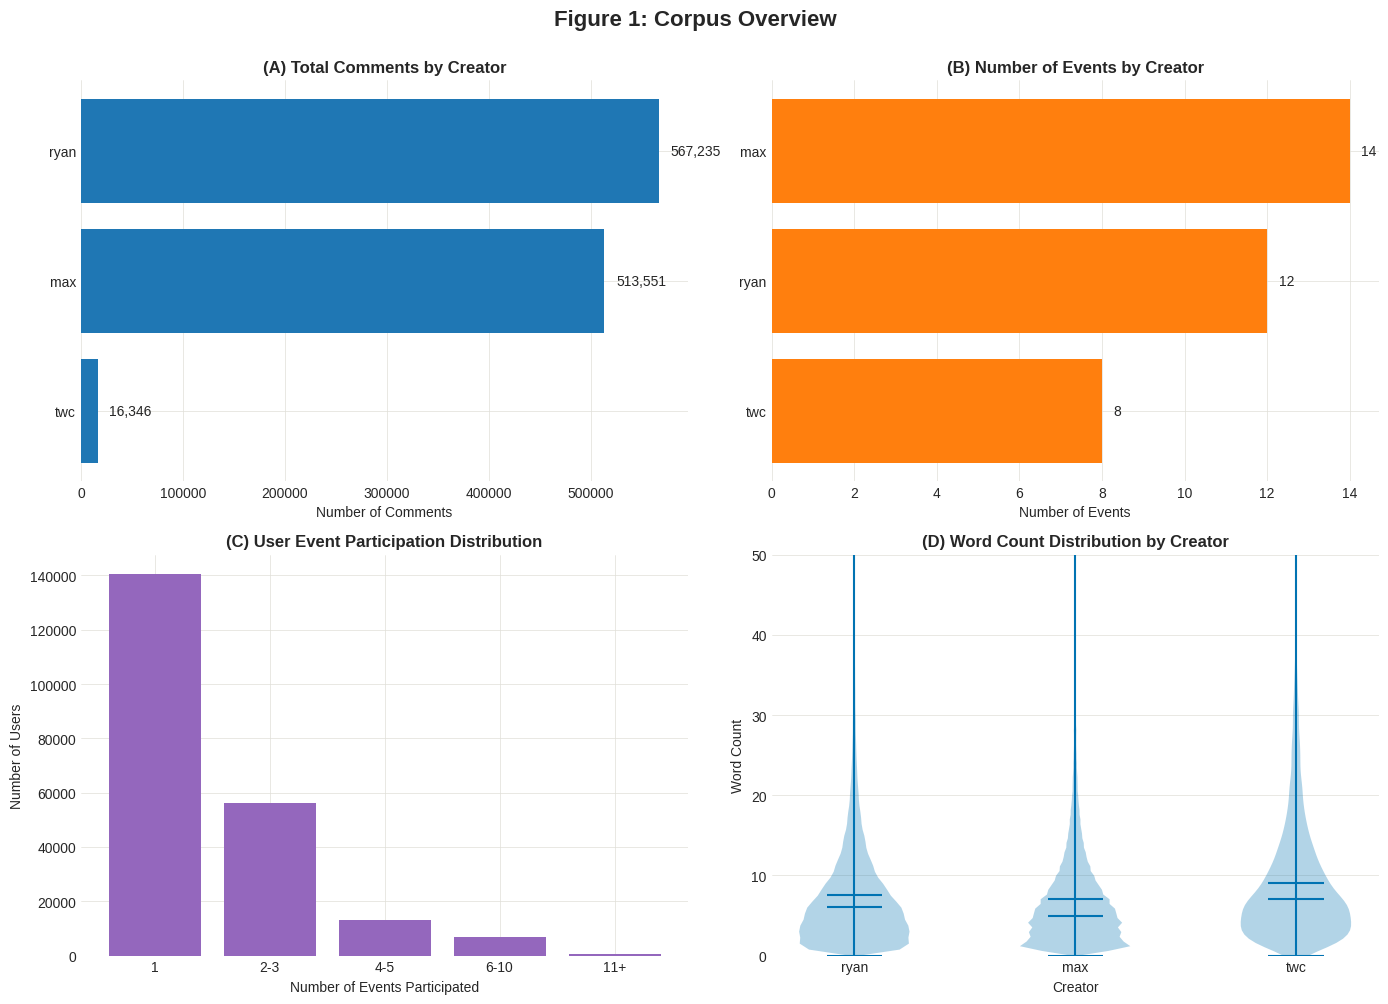

In [39]:
print("="*80)
print("SECTION 6: PUBLICATION-READY VISUALIZATIONS")
print("="*80)

# Figure 1: 4-panel corpus overview
print("\nFigure 1: Corpus Overview (4-panel)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 1: Corpus Overview', fontsize=16, fontweight='bold', y=1.00)

# Panel A: Total comments by creator
comments_by_creator = df_human.groupby('creator').size().sort_values(ascending=True)
axes[0, 0].barh(comments_by_creator.index, comments_by_creator.values, color='#1f77b4')
axes[0, 0].set_title('(A) Total Comments by Creator', fontweight='bold')
axes[0, 0].set_xlabel('Number of Comments')
axes[0, 0].ticklabel_format(style='plain', axis='x')
for i, v in enumerate(comments_by_creator.values):
    axes[0, 0].text(v + max(comments_by_creator.values)*0.02, i, f'{v:,}', va='center')

# Panel B: Events by creator
events_by_creator = df_human.groupby('creator')['event_date'].nunique().sort_values(ascending=True)
axes[0, 1].barh(events_by_creator.index, events_by_creator.values, color='#ff7f0e')
axes[0, 1].set_title('(B) Number of Events by Creator', fontweight='bold')
axes[0, 1].set_xlabel('Number of Events')
for i, v in enumerate(events_by_creator.values):
    axes[0, 1].text(v + max(events_by_creator.values)*0.02, i, f'{v}', va='center')

# Panel C: User participation distribution
event_participation_dist = df_human.groupby('username')['event_date'].nunique().value_counts().sort_index()
participation_bins = pd.cut(event_participation_dist.index, bins=[0, 1, 3, 5, 10, 20], labels=['1', '2-3', '4-5', '6-10', '11+'])
binned_participation = event_participation_dist.groupby(participation_bins).sum()
axes[1, 0].bar(binned_participation.index.astype(str), binned_participation.values, color='#9467bd')
axes[1, 0].set_title('(C) User Event Participation Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Number of Events Participated')
axes[1, 0].set_ylabel('Number of Users')
axes[1, 0].ticklabel_format(style='plain', axis='y')

# Panel D: Word count distribution by creator (violin plot)
creator_order = ['ryan', 'max', 'twc']
data_for_violin = [df_human[df_human['creator'] == c]['word_count'].values for c in creator_order]
parts = axes[1, 1].violinplot(data_for_violin, positions=range(len(creator_order)), showmeans=True, showmedians=True)
axes[1, 1].set_title('(D) Word Count Distribution by Creator', fontweight='bold')
axes[1, 1].set_xlabel('Creator')
axes[1, 1].set_ylabel('Word Count')
axes[1, 1].set_xticks(range(len(creator_order)))
axes[1, 1].set_xticklabels(creator_order)
axes[1, 1].set_ylim(0, 50)  # Truncate for visibility

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig1_corpus_overview.png', dpi=300, bbox_inches='tight')
print("✓ Figure 1 saved")
plt.show()


Figure 2: Data Filtering Impact
✓ Figure 2 saved


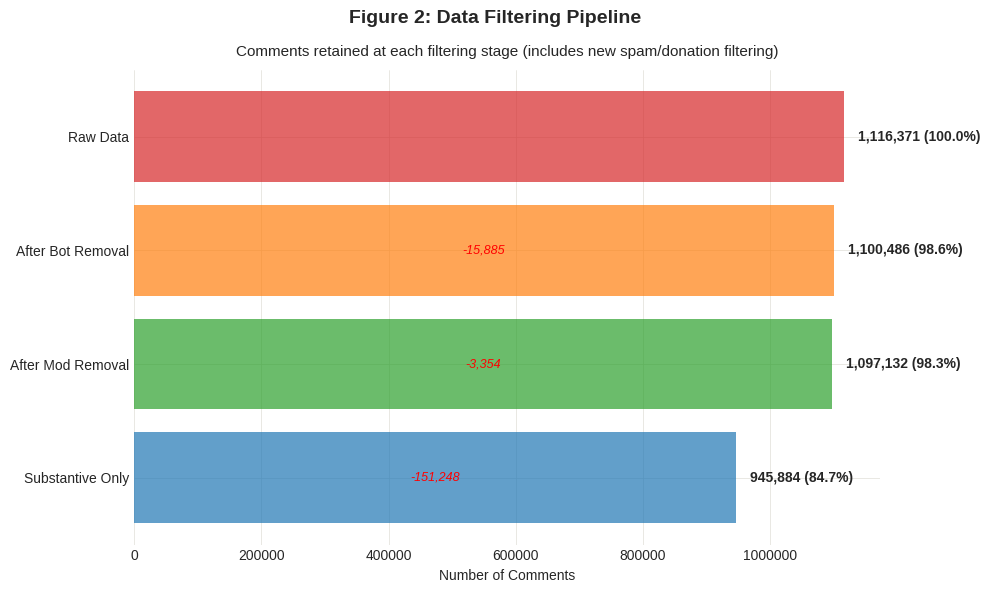

In [40]:
# Figure 2: Data Filtering Impact (Sankey-style)
print("\nFigure 2: Data Filtering Impact")

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Figure 2: Data Filtering Pipeline', fontsize=14, fontweight='bold')

# Calculate filtering stages
stages = [
    ('Raw Data', len(df)),
    ('After Bot Removal', len(df[~df['is_bot']])),
    ('After Mod Removal', len(df_human)),
    ('Substantive Only', len(df_sample_frame))
]

stage_names = [s[0] for s in stages]
stage_counts = [s[1] for s in stages]
stage_pcts = [100 * count / stages[0][1] for count in stage_counts]

# Create bar chart with annotations
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
bars = ax.barh(stage_names, stage_counts, color=colors, alpha=0.7)

# Add count and percentage labels
for i, (bar, count, pct) in enumerate(zip(bars, stage_counts, stage_pcts)):
    ax.text(count + max(stage_counts)*0.02, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)', va='center', fontweight='bold')

    # Show what was removed between stages
    if i > 0:
        removed = stage_counts[i-1] - count
        ax.text(count/2, bar.get_y() + bar.get_height()/2,
                f'-{removed:,}', va='center', ha='center',
                color='red', fontsize=9, style='italic')

ax.set_xlabel('Number of Comments')
ax.set_title('Comments retained at each filtering stage (includes new spam/donation filtering)', fontsize=11, pad=10)
ax.ticklabel_format(style='plain', axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig2_filtering_impact.png', dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved")
plt.show()


Figure 3: Temporal Comment Velocity
✓ Figure 3 saved


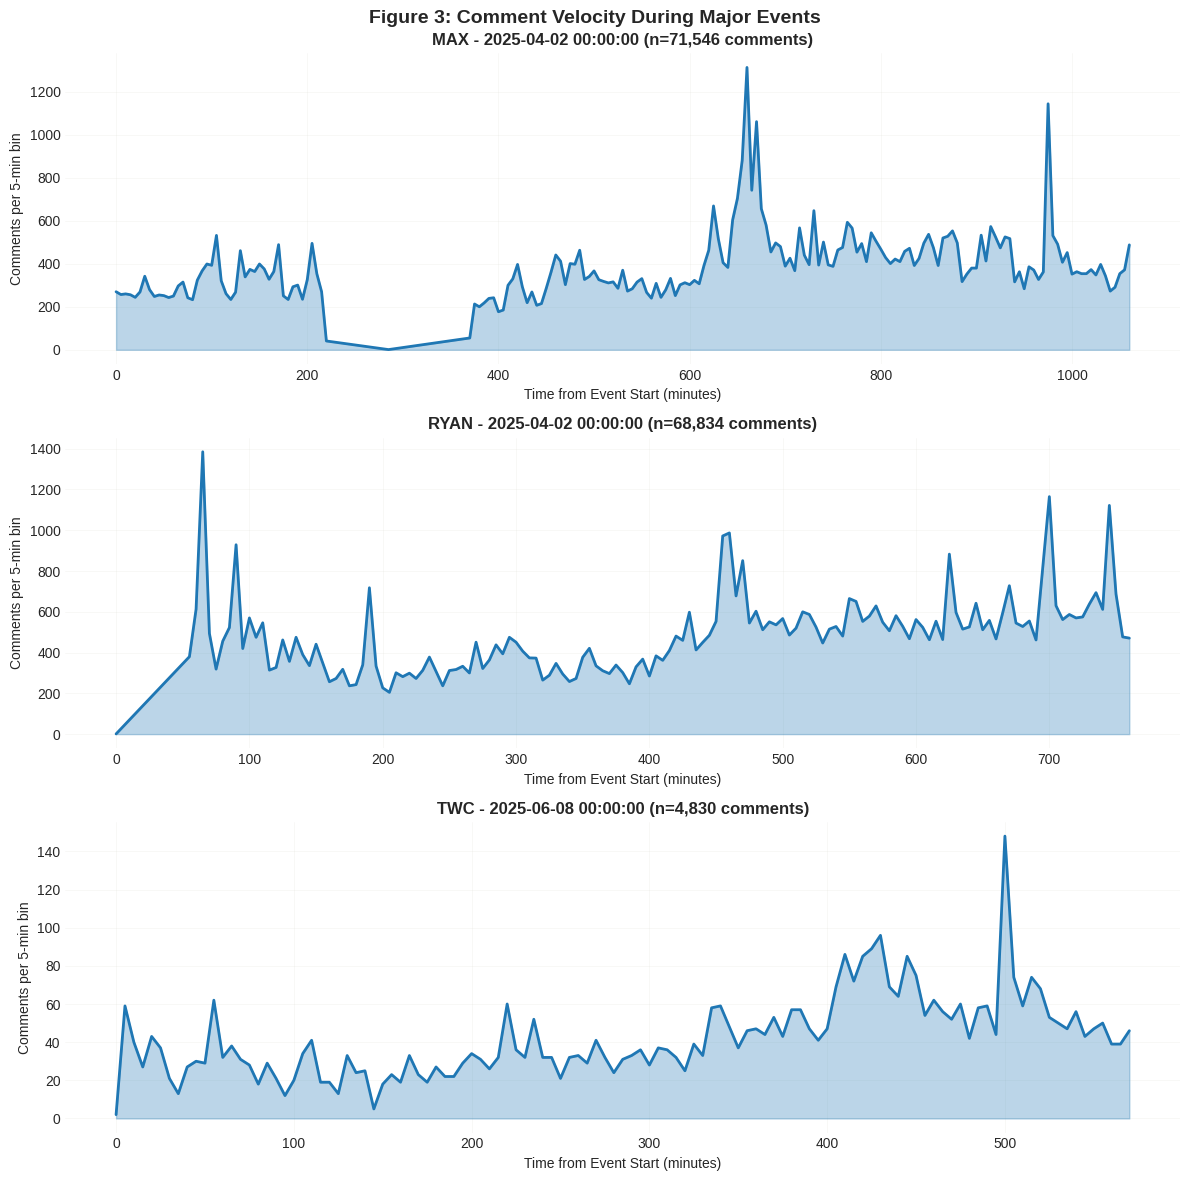

In [41]:
# Figure 3: Temporal Comment Velocity (example for largest event per creator)
print("\nFigure 3: Temporal Comment Velocity")

# Get largest event per creator
largest_events = df_sample_frame.groupby(['creator', 'event_date']).size().reset_index(name='count')
largest_events = largest_events.sort_values('count', ascending=False).groupby('creator').first().reset_index()

fig, axes = plt.subplots(len(largest_events), 1, figsize=(12, 4*len(largest_events)))
fig.suptitle('Figure 3: Comment Velocity During Major Events', fontsize=14, fontweight='bold')

if len(largest_events) == 1:
    axes = [axes]

for idx, (ax, (_, event_row)) in enumerate(zip(axes, largest_events.iterrows())):
    creator = event_row['creator']
    event_date = event_row['event_date']

    # Get comments for this event
    event_data = df_sample_frame[
        (df_sample_frame['creator'] == creator) &
        (df_sample_frame['event_date'] == event_date)
    ].copy()

    # Calculate comments per 5-minute bin
    event_data['time_bin'] = (event_data['time_from_event_start'] // 5) * 5
    velocity = event_data.groupby('time_bin').size()

    ax.plot(velocity.index, velocity.values, linewidth=2, color='#1f77b4')
    ax.fill_between(velocity.index, velocity.values, alpha=0.3, color='#1f77b4')
    ax.set_title(f'{creator.upper()} - {event_date} (n={len(event_data):,} comments)', fontweight='bold')
    ax.set_xlabel('Time from Event Start (minutes)')
    ax.set_ylabel('Comments per 5-min bin')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fig3_temporal_velocity.png', dpi=300, bbox_inches='tight')
print("✓ Figure 3 saved")
plt.show()

---
## SECTION 7: Generate Coding Sample - REVISED SAMPLING STRATEGY

In [42]:
print("="*80)
print("SECTION 7: GENERATE CODING SAMPLE - REVISED STRATEGY")
print("="*80)

# Include all three creators in sampling frame
df_for_sampling = df_sample_frame.copy()

# 🆕 NEW: Apply temporal exclusion - remove first 15 minutes of each event
EXCLUSION_WINDOW_MINUTES = 15
print(f"\n🆕 Applying temporal exclusion: removing first {EXCLUSION_WINDOW_MINUTES} minutes of each stream...")
print("   Rationale: Reduces greeting bias ('hi max', 'hey ryan', etc.)\n")

df_for_sampling = df_for_sampling[df_for_sampling['time_from_event_start'] >= EXCLUSION_WINDOW_MINUTES].copy()

print(f"Sampling frame (all creators, after temporal exclusion): {len(df_for_sampling):,} comments")
print(f"\nBreakdown:")
print(df_for_sampling.groupby('creator').size())
print(f"\nEvents per creator:")
events_per_creator = df_for_sampling.groupby('creator')['event_date'].nunique()
print(events_per_creator)

# Calculate total events for allocation
total_events = events_per_creator.sum()
removed_count = len(df_sample_frame) - len(df_for_sampling)
print(f"\n✓ {removed_count:,} comments removed from first {EXCLUSION_WINDOW_MINUTES} minutes")

SECTION 7: GENERATE CODING SAMPLE - REVISED STRATEGY

🆕 Applying temporal exclusion: removing first 15 minutes of each stream...
   Rationale: Reduces greeting bias ('hi max', 'hey ryan', etc.)

Sampling frame (all creators, after temporal exclusion): 934,391 comments

Breakdown:
creator
max     435506
ryan    484736
twc      14149
dtype: int64

Events per creator:
creator
max     14
ryan    12
twc      8
Name: event_date, dtype: int64

✓ 11,493 comments removed from first 15 minutes


In [21]:
print("\n🆕 Calculating stratified sample allocation (proportional with floor)...")
print("-" * 80)

TARGET_TOTAL = 2000
MIN_PER_EVENT = 30  # Floor to ensure every event is represented

# Calculate proportional allocation across all three creators
total_events = df_for_sampling.groupby('creator')['event_date'].nunique().sum()

# Reserve floor allocation for all events first
total_floor = total_events * MIN_PER_EVENT
remaining_to_allocate = TARGET_TOTAL - total_floor

print(f"\nTotal events across all creators: {total_events}")
print(f"Total floor allocation ({MIN_PER_EVENT} per event): {total_floor}")
print(f"Remaining to allocate proportionally: {remaining_to_allocate}")

sampling_plan = []

# First pass: Calculate proportions and allocate
creator_allocations = {}
for creator in ['ryan', 'max', 'twc']:
    creator_data = df_for_sampling[df_for_sampling['creator'] == creator]
    creator_proportion = len(creator_data) / len(df_for_sampling)
    creator_allocations[creator] = {
        'data': creator_data,
        'proportion': creator_proportion,
        'proportional_raw': creator_proportion * remaining_to_allocate,
        'events': creator_data['event_date'].nunique()
    }

# Allocate with proper rounding to preserve total
allocated_so_far = 0
for i, (creator, info) in enumerate(creator_allocations.items()):
    if i < len(creator_allocations) - 1:
        # Round normally for first creators
        proportional = round(info['proportional_raw'])
    else:
        # Last creator gets whatever's left to hit the target exactly
        proportional = remaining_to_allocate - allocated_so_far

    creator_allocations[creator]['proportional'] = proportional
    allocated_so_far += proportional

# Now build sampling plan with the corrected allocations
for creator in ['ryan', 'max', 'twc']:
    info = creator_allocations[creator]
    creator_data = info['data']
    creator_events = creator_data['event_date'].unique()
    n_events = info['events']
    proportional = info['proportional']

    creator_floor_total = n_events * MIN_PER_EVENT
    creator_target_total = creator_floor_total + proportional

    print(f"\n{creator.upper()}:")
    print(f"  Events: {n_events}")
    print(f"  Comments available: {len(creator_data):,}")
    print(f"  Proportion of corpus: {info['proportion']*100:.1f}%")
    print(f"  Floor allocation ({MIN_PER_EVENT} × {n_events}): {creator_floor_total}")
    print(f"  Proportional allocation: {proportional}")
    print(f"  Total target: {creator_target_total}")

    # Calculate event-level allocation within creator
    event_sizes = {}
    for event in creator_events:
        event_data = creator_data[creator_data['event_date'] == event]
        event_sizes[event] = len(event_data)

    total_creator_comments = sum(event_sizes.values())

    # Allocate to events with better rounding
    event_allocations = {}
    allocated_proportional = 0
    sorted_events = sorted(creator_events)

    for i, event in enumerate(sorted_events):
        event_proportion = event_sizes[event] / total_creator_comments

        if i < len(sorted_events) - 1:
            # Round normally
            event_proportional = round(event_proportion * proportional)
        else:
            # Last event gets remainder to hit target exactly
            event_proportional = proportional - allocated_proportional

        event_allocations[event] = event_proportional
        allocated_proportional += event_proportional

    # Build sampling plan
    for event in creator_events:
        event_data = creator_data[creator_data['event_date'] == event]
        available = len(event_data)
        event_proportional = event_allocations[event]

        target = MIN_PER_EVENT + event_proportional
        target = min(target, available)  # Can't exceed available

        sampling_plan.append({
            'creator': creator,
            'event_date': event,
            'available': available,
            'floor': MIN_PER_EVENT,
            'proportional': event_proportional,
            'target': target,
            'pct_of_event': (target / available * 100)
        })

sampling_plan_df = pd.DataFrame(sampling_plan)
print(f"\nSampling Plan:")
print(sampling_plan_df[['creator', 'event_date', 'available', 'floor', 'proportional', 'target', 'pct_of_event']].to_string(index=False))
print(f"\nTotal target: {sampling_plan_df['target'].sum()}")
print(f"\nSamples by creator:")
creator_totals = sampling_plan_df.groupby('creator')['target'].sum()
for creator, total in creator_totals.items():
    print(f"  {creator.upper()}: {total}")
print(f"\nSampling rates by event size:")
print(f"  Smallest event: {sampling_plan_df['pct_of_event'].min():.2f}%")
print(f"  Largest event: {sampling_plan_df['pct_of_event'].max():.2f}%")
print(f"  Mean: {sampling_plan_df['pct_of_event'].mean():.2f}%")


🆕 Calculating stratified sample allocation (proportional with floor)...
--------------------------------------------------------------------------------

Total events across all creators: 34
Total floor allocation (30 per event): 1020
Remaining to allocate proportionally: 980

RYAN:
  Events: 12
  Comments available: 484,736
  Proportion of corpus: 51.9%
  Floor allocation (30 × 12): 360
  Proportional allocation: 508
  Total target: 868

MAX:
  Events: 14
  Comments available: 435,506
  Proportion of corpus: 46.6%
  Floor allocation (30 × 14): 420
  Proportional allocation: 457
  Total target: 877

TWC:
  Events: 8
  Comments available: 14,149
  Proportion of corpus: 1.5%
  Floor allocation (30 × 8): 240
  Proportional allocation: 15
  Total target: 255

Sampling Plan:
creator event_date  available  floor  proportional  target  pct_of_event
   ryan 2025-03-14      45198     30            47      77          0.17
   ryan 2025-03-15      35565     30            37      67          0.19

In [22]:
print("\n🆕 Generating stratified random sample (HALF-HOURLY BLOCK STRATEGY)...")
print("-" * 80)
print("NEW APPROACH: Sampling evenly by 30-minute blocks rather than proportionally by hour")
print("RATIONALE: Reduces over-sampling of high-frequency question periods\n")

# Draw the sample using NEW half-hourly block strategy
coding_samples = []

for _, row in sampling_plan_df.iterrows():
    creator = row['creator']
    event = row['event_date']
    n_sample = int(row['target'])

    event_data = df_for_sampling[
        (df_for_sampling['creator'] == creator) &
        (df_for_sampling['event_date'] == event)
    ].copy()

    # 🆕 NEW: Divide into 30-minute blocks instead of hourly
    # Create half-hour bins (0-30, 30-60, 60-90, etc.)
    event_data['half_hour_block'] = (event_data['time_from_event_start'] // 30).astype(int)

    # Get blocks that have comments
    blocks_with_comments = event_data['half_hour_block'].unique()
    n_blocks = len(blocks_with_comments)

    if n_blocks == 0:
        print(f"  WARNING: No blocks found for {creator} {event}")
        continue

    # Distribute samples evenly across blocks
    base_per_block = n_sample // n_blocks
    extra_samples = n_sample % n_blocks

    # Sample from each block
    event_samples = []
    for i, block in enumerate(sorted(blocks_with_comments)):
        block_data = event_data[event_data['half_hour_block'] == block]

        # Allocate samples for this block
        block_target = base_per_block + (1 if i < extra_samples else 0)
        block_target = min(block_target, len(block_data))  # Can't exceed available

        if block_target > 0:
            # Change random_state to `None` for different results each run, or a different integer for new but reproducible results.
            block_sample = block_data.sample(n=block_target, random_state=33) # Changed from random_state=42
            event_samples.append(block_sample)

    if event_samples:
        event_sample = pd.concat(event_samples)
        coding_samples.append(event_sample)

# Combine all samples
coding_sample = pd.concat(coding_samples, ignore_index=True)

print(f"\n✓ Sample generated: {len(coding_sample):,} comments")
print(f"\nSample distribution:")
print(coding_sample.groupby('creator').size())
print(f"\nSample by creator and event:")
sample_dist = coding_sample.groupby(['creator', 'event_date']).size().reset_index(name='n')
print(sample_dist.to_string(index=False))


🆕 Generating stratified random sample (HALF-HOURLY BLOCK STRATEGY)...
--------------------------------------------------------------------------------
NEW APPROACH: Sampling evenly by 30-minute blocks rather than proportionally by hour
RATIONALE: Reduces over-sampling of high-frequency question periods


✓ Sample generated: 1,982 comments

Sample distribution:
creator
max     875
ryan    865
twc     242
dtype: int64

Sample by creator and event:
creator event_date   n
    max 2025-03-14  82
    max 2025-03-15  67
    max 2025-03-16  51
    max 2025-04-02 102
    max 2025-04-03  45
    max 2025-04-04  59
    max 2025-04-05  60
    max 2025-05-15  58
    max 2025-05-16  66
    max 2025-05-17  37
    max 2025-05-18  68
    max 2025-05-19  70
    max 2025-05-20  62
    max 2025-06-20  48
   ryan 2025-03-14  77
   ryan 2025-03-15  67
   ryan 2025-04-02 102
   ryan 2025-04-03  68
   ryan 2025-04-04  64
   ryan 2025-04-05  72
   ryan 2025-05-15  68
   ryan 2025-05-16  83
   ryan 2025-05-18  

In [23]:
print(sampling_plan_df[['creator','event_date','available',
                         'floor','proportional','target','pct_of_event']]
      .sort_values(['creator','event_date'])
      .to_string(index=False))

creator event_date  available  floor  proportional  target  pct_of_event
    max 2025-03-14      49458     30            52      82          0.17
    max 2025-03-15      35196     30            37      67          0.19
    max 2025-03-16      19901     30            21      51          0.26
    max 2025-04-02      70759     30            74     104          0.15
    max 2025-04-03      14570     30            15      45          0.31
    max 2025-04-04      28031     30            29      59          0.21
    max 2025-04-05      28488     30            30      60          0.21
    max 2025-05-15      26830     30            28      58          0.22
    max 2025-05-16      34069     30            36      66          0.19
    max 2025-05-17       6670     30             7      37          0.55
    max 2025-05-18      36667     30            38      68          0.19
    max 2025-05-19      37776     30            40      70          0.19
    max 2025-05-20      30095     30            32 

In [24]:
print(sampling_plan_df[['creator','event_date','available',
                         'floor','proportional','target','pct_of_event']]
      .sort_values(['creator','event_date'])
      .to_string(index=False))

creator event_date  available  floor  proportional  target  pct_of_event
    max 2025-03-14      49458     30            52      82          0.17
    max 2025-03-15      35196     30            37      67          0.19
    max 2025-03-16      19901     30            21      51          0.26
    max 2025-04-02      70759     30            74     104          0.15
    max 2025-04-03      14570     30            15      45          0.31
    max 2025-04-04      28031     30            29      59          0.21
    max 2025-04-05      28488     30            30      60          0.21
    max 2025-05-15      26830     30            28      58          0.22
    max 2025-05-16      34069     30            36      66          0.19
    max 2025-05-17       6670     30             7      37          0.55
    max 2025-05-18      36667     30            38      68          0.19
    max 2025-05-19      37776     30            40      70          0.19
    max 2025-05-20      30095     30            32 

In [25]:
print("\n🆕 Analyzing temporal distribution of sample...")
print("-" * 80)
print("Checking if half-hourly block strategy produced more even temporal distribution:\n")

# Analyze temporal distribution
for creator in ['ryan', 'max']:
    creator_sample = coding_sample[coding_sample['creator'] == creator]

    # Group by 30-minute blocks
    creator_sample_analysis = creator_sample.copy()
    creator_sample_analysis['half_hour_block'] = (creator_sample_analysis['time_from_event_start'] // 30).astype(int)

    block_dist = creator_sample_analysis['half_hour_block'].value_counts().sort_index()

    print(f"{creator.upper()} - Comments per 30-minute block (across all events):")
    print(f"  Mean: {block_dist.mean():.1f}")
    print(f"  Std Dev: {block_dist.std():.1f}")
    print(f"  Min: {block_dist.min()}")
    print(f"  Max: {block_dist.max()}")
    print(f"  Coefficient of Variation: {(block_dist.std() / block_dist.mean()):.2f}")
    print(f"  (Lower CV = more even distribution)\n")


🆕 Analyzing temporal distribution of sample...
--------------------------------------------------------------------------------
Checking if half-hourly block strategy produced more even temporal distribution:

RYAN - Comments per 30-minute block (across all events):
  Mean: 21.6
  Std Dev: 16.6
  Min: 1
  Max: 46
  Coefficient of Variation: 0.77
  (Lower CV = more even distribution)

MAX - Comments per 30-minute block (across all events):
  Mean: 18.6
  Std Dev: 9.2
  Min: 3
  Max: 35
  Coefficient of Variation: 0.50
  (Lower CV = more even distribution)



In [26]:
# Export the coding sample
EXPORT_PATH = '/content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[In Progress] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/coding_sample_2000_stratified_FOR_CODING.csv'

coding_sample.to_csv(EXPORT_PATH, index=False)
print(f"\n✓ Coding sample exported to: {EXPORT_PATH}")
print(f"   Total samples: {len(coding_sample):,}")
print(f"   Ready for manual coding!")


✓ Coding sample exported to: /content/drive/MyDrive/**CORE PROJECTS - Julie/[PROJECTS PAPERS]/ACTIVE IN-PROGRESS STUDIES/[In Progress] [DS3] Trust Behaviors in Collective Chat/Data/All YouTube Data/coding_sample_2000_stratified_FOR_CODING.csv
   Total samples: 1,982
   Ready for manual coding!


---
## SECTION 8: Export Summary Tables

Creating summary tables for paper's methods section.

In [27]:
print("="*80)
print("SECTION 8: EXPORT SUMMARY TABLES")
print("="*80)

# Table 1: Corpus Overview (by creator)
print("\nTable 1: Corpus Overview")
table1 = df_human.groupby('creator').agg({
    'comment_text': 'count',
    'username': 'nunique',
    'event_date': 'nunique',
    'word_count': ['mean', 'median']
}).round(2)
table1.columns = ['total_comments', 'unique_users', 'events', 'mean_word_count', 'median_word_count']
table1.to_csv('/content/drive/MyDrive/table1_corpus_overview.csv')
print(table1)
print("✓ Table 1 exported")

SECTION 8: EXPORT SUMMARY TABLES

Table 1: Corpus Overview
         total_comments  unique_users  events  mean_word_count  \
creator                                                          
max              513195         81953      14             7.05   
ryan             566515        148363      12             7.57   
twc               16338          3767       8             9.00   

         median_word_count  
creator                     
max                   5.00  
ryan                  6.00  
twc                   7.00  
✓ Table 1 exported


In [28]:
# Table 2: Data Filtering Impact
print("\nTable 2: Data Filtering Pipeline (🆕 includes spam/donation filtering)")

# Calculate totals at each stage
filtering_stages = [
    ('Raw Data', len(df)),
    ('After Bot Removal', len(df[~df['is_bot']])),
    ('After Mod Removal', len(df_human)),
    ('After Low-Effort Filtering', len(df_human[~(
        df_human['is_one_word'] |
        df_human['is_interjection'] |
        df_human['is_all_caps_single'] |
        df_human['is_punctuation_only'] |
        df_human['is_emoji_only'] |
        df_human['is_greeting']
    )])),
    ('After Spam/Donation Filtering (FINAL)', len(df_sample_frame)),
]

table2 = pd.DataFrame(filtering_stages, columns=['Stage', 'Comments_Remaining'])
table2['Removed'] = table2['Comments_Remaining'].shift(1) - table2['Comments_Remaining']
table2['Removed'] = table2['Removed'].fillna(0).astype(int)
table2['Percent_Retained'] = (table2['Comments_Remaining'] / filtering_stages[0][1] * 100).round(2)

table2.to_csv('/content/drive/MyDrive/table2_filtering_impact.csv', index=False)
print(table2.to_string(index=False))
print("✓ Table 2 exported")


Table 2: Data Filtering Pipeline (🆕 includes spam/donation filtering)
                                Stage  Comments_Remaining  Removed  Percent_Retained
                             Raw Data             1116371        0            100.00
                    After Bot Removal             1100486    15885             98.58
                    After Mod Removal             1097132     3354             98.28
           After Low-Effort Filtering              965609   131523             86.50
After Spam/Donation Filtering (FINAL)              945884    19725             84.73
✓ Table 2 exported


In [29]:
# Table 3: Coding Sample Characteristics (🆕 REVISED sampling strategy)
print("\nTable 3: Coding Sample Characteristics (🆕 REVISED: half-hourly blocks + 15min exclusion)")

table3_data = []
for creator in ['ryan', 'max']:
    creator_coding = coding_sample[coding_sample['creator'] == creator]
    creator_frame = df_sample_frame[df_sample_frame['creator'] == creator]

    table3_data.append({
        'creator': creator,
        'total_substantive': len(creator_frame),
        'sampled': len(creator_coding),
        'sampling_rate_pct': round(len(creator_coding) / len(creator_frame) * 100, 2),
        'events_sampled': creator_coding['event_date'].nunique(),
        'mean_per_event': round(creator_coding.groupby('event_date').size().mean(), 1),
        'with_mentions_n': creator_coding['has_mention'].sum(),
        'with_mentions_pct': round(creator_coding['has_mention'].sum() / len(creator_coding) * 100, 1)
    })

table3 = pd.DataFrame(table3_data)
table3.to_csv('/content/drive/MyDrive/table3_coding_sample_characteristics.csv', index=False)
print(table3.to_string(index=False))
print("✓ Table 3 exported")


Table 3: Coding Sample Characteristics (🆕 REVISED: half-hourly blocks + 15min exclusion)
creator  total_substantive  sampled  sampling_rate_pct  events_sampled  mean_per_event  with_mentions_n  with_mentions_pct
   ryan             492559      865               0.18              12           72.10               18               2.10
    max             438376      875               0.20              14           62.50               53               6.10
✓ Table 3 exported


In [30]:
# Event-level summary table
print("\nEvent-Level Summary")

event_summary = df_sample_frame.groupby(['creator', 'event_date']).agg({
    'comment_text': 'count',
    'username': 'nunique',
    'time_from_event_start': 'max',
    'word_count': ['mean', 'median']
}).round(2)

event_summary.columns = ['total_comments', 'unique_users', 'duration_minutes', 'mean_words', 'median_words']
event_summary = event_summary.reset_index()

# Add coding sample info
coding_by_event = coding_sample.groupby(['creator', 'event_date']).size().reset_index(name='sampled_n')
event_summary = event_summary.merge(coding_by_event, on=['creator', 'event_date'], how='left')
event_summary['sampled_n'] = event_summary['sampled_n'].fillna(0).astype(int)

event_summary.to_csv('/content/drive/MyDrive/event_level_summary.csv', index=False)
print(event_summary.to_string(index=False))
print("\n✓ Event-level summary exported")


Event-Level Summary
creator event_date  total_comments  unique_users  duration_minutes  mean_words  median_words  sampled_n
    max 2025-03-14           49458         14410            731.00        7.76          6.00         82
    max 2025-03-15           35196         11168           1142.45        7.93          6.00         67
    max 2025-03-16           20827          7020            219.92        8.23          7.00         51
    max 2025-04-02           71546         20870           1062.28        7.68          6.00        102
    max 2025-04-03           15123          5291            392.67        8.37          7.00         45
    max 2025-04-04           28032          8660           1033.33        7.83          6.00         59
    max 2025-04-05           28967          7767            724.57        7.80          6.00         60
    max 2025-05-15           26831          8242           1409.02        7.52          6.00         58
    max 2025-05-16           34070         

In [31]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                          EXPORTED FILES SUMMARY                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 SUMMARY TABLES (for paper's descriptive statistics):
   • table1_corpus_overview.csv - Creator-level statistics
   • table2_filtering_impact.csv - Data filtering pipeline (🆕 includes spam/donation)
   • table3_coding_sample_characteristics.csv - Coding sample breakdown (🆕 revised strategy)
   • event_level_summary.csv - Event-level details

📝 CODING SAMPLE:
   • coding_sample_2000_stratified_REVISED.csv - 🆕 REVISED stratified sample
     (2,000 comments with half-hourly block sampling + 15min exclusion)

📈 VISUALIZATIONS (publication-ready, 300 DPI):
   • fig1_corpus_overview.png - 4-panel corpus overview
   • fig2_filtering_impact.png - Data filtering pipeline (🆕 updated)
   • fig3_temporal_velocity.png - Comment velocity during major events
   • fig4_conversation_patterns.png - @Mention and conversation analysis

╔══════════════════════════════════════════════════════════════════════════════╗
║                     🆕 KEY CHANGES IN THIS VERSION                          ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. ✅ Added spam/donation detection and filtering
2. ✅ Revised sampling: 15-minute exclusion window for greeting bias
3. ✅ Revised sampling: Half-hourly blocks instead of proportional-hourly
4. ✅ Improved @mention analysis documentation (explains spam example)
5. ✅ Updated all tables and figures to reflect new filtering

╔══════════════════════════════════════════════════════════════════════════════╗
║                            NEXT STEPS                                        ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. ✅ Review visualizations and summary tables
2. ✅ Begin manual coding using coding_sample_2000_stratified_REVISED.csv
3. ✅ Use summary tables for dissertation's methods section
4. ✅ Document sampling strategy changes in methods
5. ✅ Integrate figures into CHI/CSCW paper

📧 Questions or need further adjustments? Let me know!
""")


ANALYSIS COMPLETE!

╔══════════════════════════════════════════════════════════════════════════════╗
║                          EXPORTED FILES SUMMARY                              ║
╚══════════════════════════════════════════════════════════════════════════════╝

📊 SUMMARY TABLES (for paper's descriptive statistics):
   • table1_corpus_overview.csv - Creator-level statistics
   • table2_filtering_impact.csv - Data filtering pipeline (🆕 includes spam/donation)
   • table3_coding_sample_characteristics.csv - Coding sample breakdown (🆕 revised strategy)
   • event_level_summary.csv - Event-level details

📝 CODING SAMPLE:
   • coding_sample_2000_stratified_REVISED.csv - 🆕 REVISED stratified sample
     (2,000 comments with half-hourly block sampling + 15min exclusion)

📈 VISUALIZATIONS (publication-ready, 300 DPI):
   • fig1_corpus_overview.png - 4-panel corpus overview
   • fig2_filtering_impact.png - Data filtering pipeline (🆕 updated)
   • fig3_temporal_velocity.png - Comment velocity 

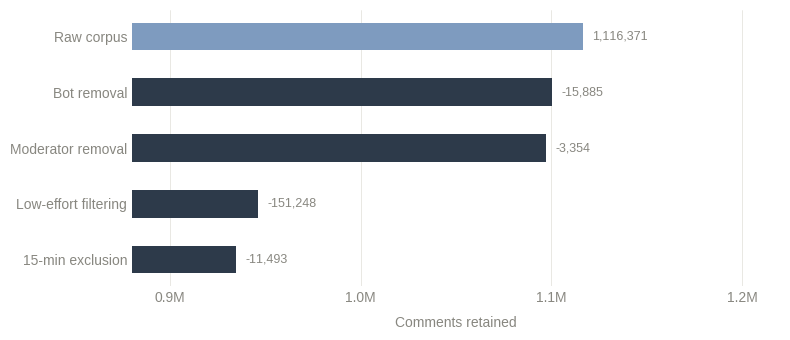

✓ Figure A saved


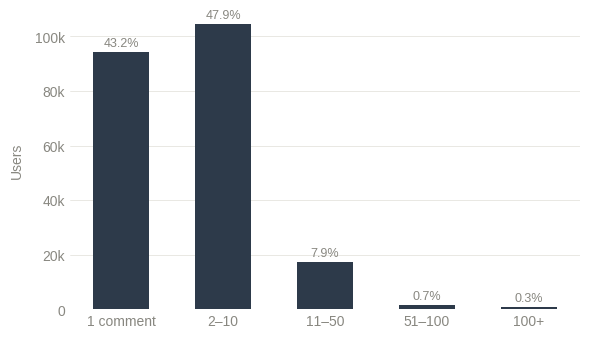

✓ Figure D saved


In [32]:
# ═══════════════════════════════════════════════════════════════════════
# SECTION 9: PUBLICATION FIGURES — Descriptive Statistics: Larger Dataset
# Requires: df (raw), user_comment_counts (Section 1, Cell 8)
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DARK  = '#2D3A4A'
LIGHT = '#7E9BBF'
MUTED = '#888780'

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': False,
    'axes.grid': True, 'grid.color': '#E0DED8', 'grid.linewidth': 0.5,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.bottom': False, 'ytick.left': False,
})

# ── Figure A: Filtering pipeline ────────────────────────────────────────

stages  = ['Raw corpus', 'Bot removal', 'Moderator removal',
           'Low-effort filtering', '15-min exclusion']
counts  = [1_116_371, 1_100_486, 1_097_132, 945_884, 934_391]
removed = ['', '-15,885', '-3,354', '-151,248', '-11,493']
colors  = [LIGHT] + [DARK] * 4

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(stages, counts, color=colors, height=0.5, zorder=3)

ax.set_xlim(880_000, 1_220_000)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(100_000))
ax.invert_yaxis()
ax.set_xlabel('Comments retained', fontsize=10, color=MUTED, labelpad=8)
ax.grid(axis='x', zorder=0)
ax.grid(axis='y', visible=False)
ax.tick_params(colors=MUTED, labelsize=10)

for bar, label, count in zip(bars, removed, counts):
    if label:
        ax.text(bar.get_width() + 5_000, bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='left', fontsize=9, color=MUTED)
    else:
        ax.text(bar.get_width() + 5_000, bar.get_y() + bar.get_height() / 2,
                f'{count:,}', va='center', ha='left', fontsize=9, color=MUTED)

plt.tight_layout()
plt.savefig('fig_A_filtering_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure A saved")


# ── Figure D: Participation skew ─────────────────────────────────────────
# Computed from user_comment_counts (created in Section 1, Cell 8)

labels_d = ['1 comment', '2–10', '11–50', '51–100', '100+']
counts_d = [
    (user_comment_counts == 1).sum(),
    ((user_comment_counts >= 2)  & (user_comment_counts <= 10)).sum(),
    ((user_comment_counts >= 11) & (user_comment_counts <= 50)).sum(),
    ((user_comment_counts >= 51) & (user_comment_counts <= 100)).sum(),
    (user_comment_counts > 100).sum()
]
total_users = sum(counts_d)
pcts_d = [c / total_users * 100 for c in counts_d]

fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(labels_d))
ax.bar(x, counts_d, color=DARK, width=0.55, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(labels_d, fontsize=10, color=MUTED)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'{int(v/1000)}k' if v >= 1000 else str(int(v))))
ax.grid(axis='y', zorder=0)
ax.grid(axis='x', visible=False)
ax.tick_params(colors=MUTED, labelsize=10)
ax.set_ylabel('Users', fontsize=10, color=MUTED, labelpad=8)

for xi, (count, pct) in enumerate(zip(counts_d, pcts_d)):
    ax.text(xi, count + 1_200, f'{pct:.1f}%',
            ha='center', va='bottom', fontsize=9, color=MUTED)

#fig.suptitle('Figure D — Comment volume distribution',
             #x=0, y=1.03, ha='left', fontsize=11, color=DARK)

#fig.text(0, -0.05,
         #f'Users by total comments posted across all events (n = {total_users:,} unique users). '
         #f'{pcts_d[0]:.1f}% of users posted once; {pcts_d[4]:.1f}% posted more than 100 comments.',
         #fontsize=9, color=MUTED, style='italic')

plt.tight_layout()
plt.savefig('fig_B_l1_by_creator.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure D saved")

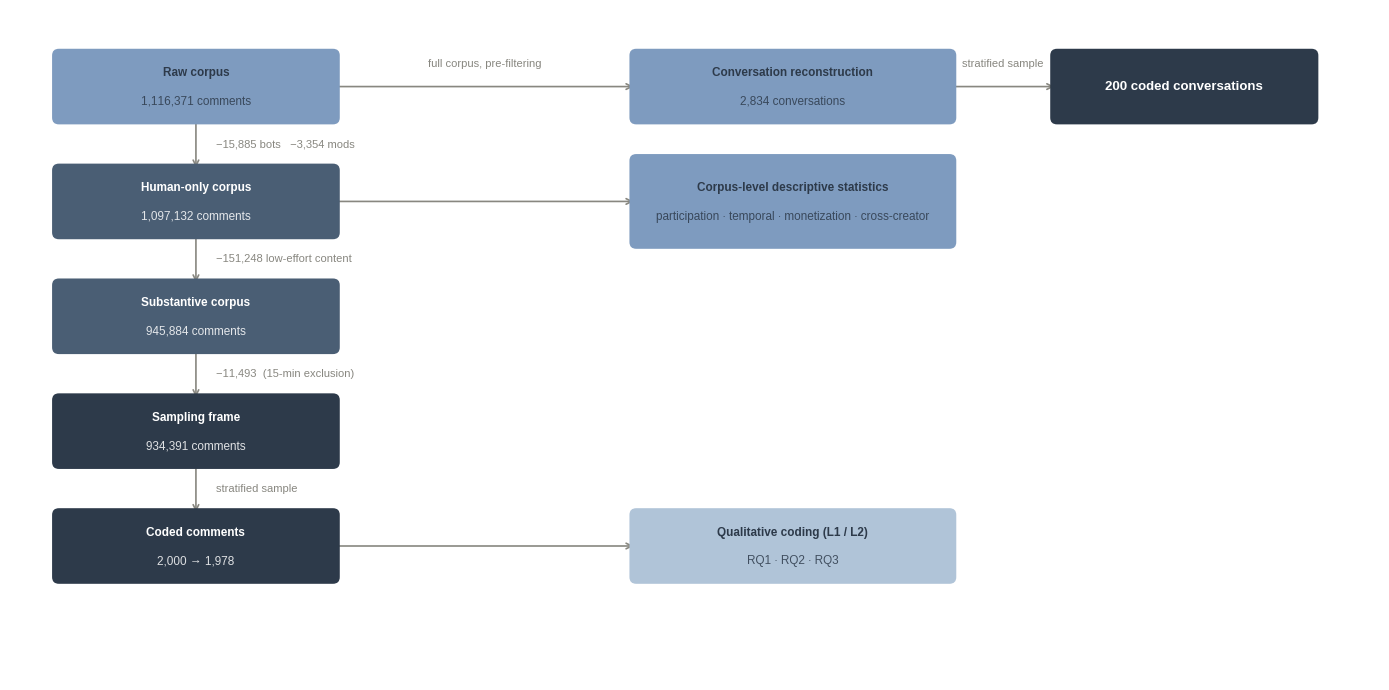

✓ Analytical pipeline figure saved


In [33]:
# ═══════════════════════════════════════════════════════════════════════
# SECTION 1C: ANALYTICAL PIPELINE DIAGRAM
# Which corpus/stage each analysis draws from
# Resolves placeholder in Data Cleaning and Filtering subsection
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DARK  = '#2D3A4A'
MID   = '#4A5E74'
LIGHT = '#7E9BBF'
PALE  = '#B0C4D8'
MUTED = '#888780'
WHITE = '#FFFFFF'

plt.rcParams.update({'font.family': 'sans-serif', 'figure.facecolor': 'white'})

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')

BW = 2.8   # main pipeline box width
BH = 0.65  # box height

def draw_box(cx, cy, w, h, facecolor, line1, line2=None, tc=WHITE):
    patch = mpatches.FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle='round,pad=0.07', facecolor=facecolor,
        edgecolor='none', zorder=3
    )
    ax.add_patch(patch)
    if line2:
        ax.text(cx, cy + 0.14, line1, ha='center', va='center',
                fontsize=8.5, fontweight='bold', color=tc, zorder=4)
        ax.text(cx, cy - 0.16, line2, ha='center', va='center',
                fontsize=8.5, color=tc, alpha=0.85, zorder=4)
    else:
        ax.text(cx, cy, line1, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color=tc, zorder=4)

def arrow_down(cx, y_upper, y_lower, label=''):
    y1 = y_upper - BH/2
    y2 = y_lower + BH/2
    ax.annotate('', xy=(cx, y2), xytext=(cx, y1),
                arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2), zorder=2)
    if label:
        ax.text(cx + 0.2, (y1 + y2)/2, label,
                fontsize=8, color=MUTED, va='center')

def arrow_right(y, x1_cx, w1, x2_cx, w2, label=''):
    xs = x1_cx + w1/2
    xe = x2_cx - w2/2
    ax.annotate('', xy=(xe, y), xytext=(xs, y),
                arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2), zorder=2)
    if label:
        ax.text((xs + xe)/2, y + 0.18, label,
                fontsize=8, color=MUTED, ha='center', va='bottom')

# ── Left column: filtering pipeline ─────────────────────────────────────
CX   = 1.9
ROWS = [6.2, 5.0, 3.8, 2.6, 1.4]

draw_box(CX, ROWS[0], BW, BH, LIGHT, 'Raw corpus',         '1,116,371 comments', DARK)
draw_box(CX, ROWS[1], BW, BH, MID,   'Human-only corpus',  '1,097,132 comments')
draw_box(CX, ROWS[2], BW, BH, MID,   'Substantive corpus', '945,884 comments')
draw_box(CX, ROWS[3], BW, BH, DARK,  'Sampling frame',     '934,391 comments')
draw_box(CX, ROWS[4], BW, BH, DARK,  'Coded comments',     '2,000 → 1,978')

arrow_down(CX, ROWS[0], ROWS[1], '−15,885 bots   −3,354 mods')
arrow_down(CX, ROWS[1], ROWS[2], '−151,248 low-effort content')
arrow_down(CX, ROWS[2], ROWS[3], '−11,493  (15-min exclusion)')
arrow_down(CX, ROWS[3], ROWS[4], 'stratified sample')

# ── Right branches ───────────────────────────────────────────────────────
RW1 = 3.2
RW2 = 2.6
CX2 = 8.0
CX3 = 12.0

# Row 0: Raw → conversation reconstruction → 200 coded conversations
draw_box(CX2, ROWS[0], RW1, BH, LIGHT,
         'Conversation reconstruction', '2,834 conversations', DARK)
draw_box(CX3, ROWS[0], RW2, BH, DARK,
         '200 coded conversations')
arrow_right(ROWS[0], CX, BW, CX2, RW1, 'full corpus, pre-filtering')
arrow_right(ROWS[0], CX2, RW1, CX3, RW2, 'stratified sample')

# Row 1: Human-only → corpus descriptive statistics
draw_box(CX2, ROWS[1], RW1, 0.85, LIGHT,
         'Corpus-level descriptive statistics',
         'participation · temporal · monetization · cross-creator', DARK)
ax.annotate('', xy=(CX2 - RW1/2, ROWS[1]), xytext=(CX + BW/2, ROWS[1]),
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2), zorder=2)

# Row 4: Coded comments → qualitative coding analysis
draw_box(CX2, ROWS[4], RW1, BH, PALE,
         'Qualitative coding (L1 / L2)', 'RQ1 · RQ2 · RQ3', DARK)
ax.annotate('', xy=(CX2 - RW1/2, ROWS[4]), xytext=(CX + BW/2, ROWS[4]),
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2), zorder=2)

plt.tight_layout()
plt.savefig('fig_analytical_pipeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Analytical pipeline figure saved")